In [1]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Define the basin states

bound_A = -0.8
bound_B = 0.8

def in_stateA(q, s):
    return q<bound_A and s == 0

def in_stateB(q, s):
    return q>bound_B and s == 0

In [3]:
# Generate seed trajectory for TPS: Madlen
# Conditions:
# --- Model ---
# eps = 0.05
# Vc = 0.2
# --- Seed trajectories ---
# v_init = -0.0087
# q_init = 1.0
# coeff_init = np.array([1.0, 0.0], dtype=complex)
# mass = 1836.15
# act_state_init = 0
# dt = 5
# max_steps = 10000000
# --- TPS setup ---
# TPS temperature = 12000K
# Sample size = 10000
# maximum trajectory length = 5000

v_init = -0.0087
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 10000000

x0 = 1.0
k = 0.1
Vc = 0.2
eps = 0.05

SHO_H = DoubleHarmonic(k=2 * eps, x0=1.0, vc=Vc * eps)
C_init = SHO_H.eigvecs(q_init)

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)

seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)

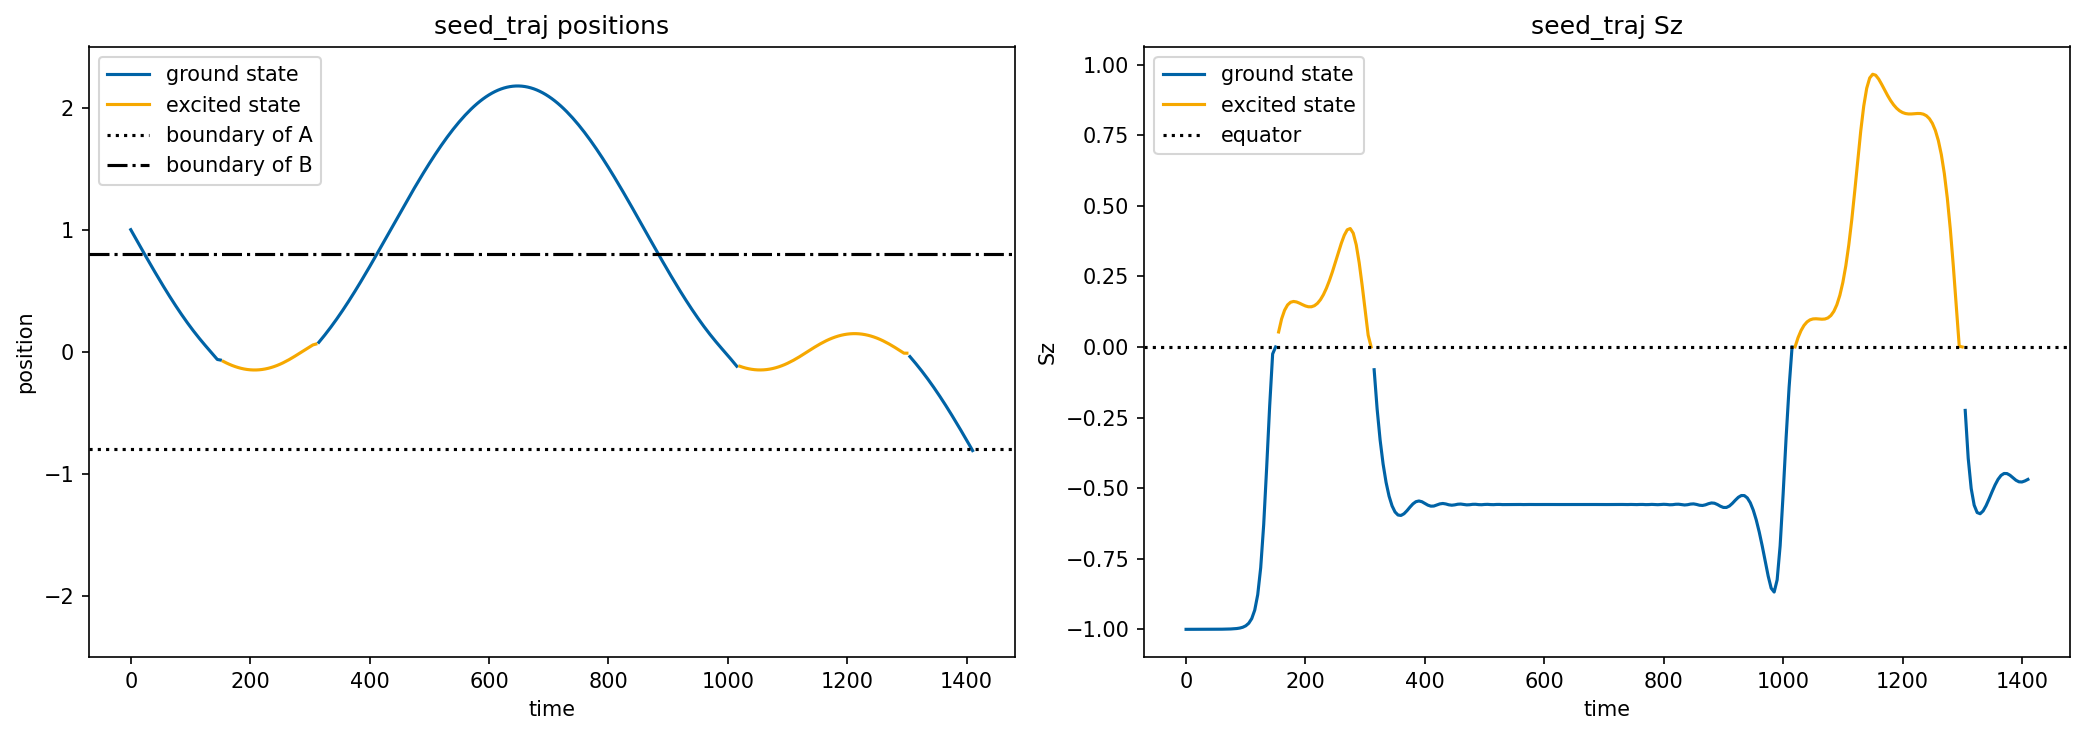

In [4]:
# PLOT SEED TRAJECTORY

labelstates = ["ground state", "excited state"]
colorstates = ["#0063A6","#F6A800","#666666"]

# --- Positions ---
oscillator_positions = np.array([seed_traj[i].positions for i in range(len(seed_traj))])
active_states = np.array([seed_traj[i].active_state for i in range(len(seed_traj))])
ground_state_positions = np.copy(oscillator_positions)
ground_state_positions[active_states > 0] = np.nan
excited_state_positions = np.copy(oscillator_positions)
excited_state_positions[active_states != 1] = np.nan

# --- Coefficients ---
oscillator_coeffs = np.array([sz_from_coeff(seed_traj[i].coefficients) for i in range(len(seed_traj))])
ground_state_coeffs = np.copy(oscillator_coeffs)
ground_state_coeffs[active_states > 0] = np.nan
excited_state_coeffs = np.copy(oscillator_coeffs)
excited_state_coeffs[active_states != 1] = np.nan

# --- Create subplots ---
fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

# Left: Positions
axes[0].plot(np.arange(len(seed_traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
axes[0].plot(np.arange(len(seed_traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
axes[0].set_xlabel("time")
axes[0].set_ylabel("position")
axes[0].set_ylim([-2.5, 2.5])
axes[0].set_title("seed_traj positions")
axes[0].legend(loc=2)

# Right: Sz
axes[1].plot(np.arange(len(seed_traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
axes[1].plot(np.arange(len(seed_traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
axes[1].set_xlabel("time")
axes[1].set_ylabel("Sz")
axes[1].set_title("seed_traj Sz")
axes[1].legend(loc=2)

plt.tight_layout()
plt.show()

In [6]:
# Main TPS proof of concept with the selected condition Page 1: main sequence

ensemble_size = 10000
max_traj_length = 5000

tps_selector = UniformShootingSelector(temp=12000, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9)
path_sampling = PathSampling(selector=tps_selector, seed_traj=seed_traj, max_iter=ensemble_size,
                             max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)

engine_builder = MASHEngine
tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)
MC_rate = path_sampling.MC_acceptance()

transit_times, mean_time, std_time = path_sampling.transit_time_statistics(tps_ensemble=tps_ensemble, dt=dt)
speedup = path_sampling.efficiency_statistics(naive_tps_ensemble=naive_tps_ensemble, mc_rate=MC_rate)

max_lag = 100
auto_correlation = path_sampling.compute_autocorrelation(data=transit_times, max_lag=max_lag)

mean_hops, std_hops, q_hops = path_sampling.hop_statistics(tps_ensemble=tps_ensemble)

grand_list = {'tps ensemble': tps_ensemble, 'naive tps ensemble': naive_tps_ensemble,
              'MC rate': MC_rate, 'transit times': transit_times, 'mean time': mean_time,
              'std time': std_time, 'autocorrelation': auto_correlation, 'mean hops': mean_hops,
              'std hops': std_hops, 'q hops': q_hops}



--- TPS Iteration 0 ---
Rejected
--- TPS Iteration 1 ---
Rejected
--- TPS Iteration 2 ---
Rejected
--- TPS Iteration 3 ---
Rejected
--- TPS Iteration 4 ---
Accepted
--- TPS Iteration 5 ---
Accepted
--- TPS Iteration 6 ---
Accepted
--- TPS Iteration 7 ---
Accepted
--- TPS Iteration 8 ---
Accepted
--- TPS Iteration 9 ---
Rejected
--- TPS Iteration 10 ---
Rejected
--- TPS Iteration 11 ---
Accepted
--- TPS Iteration 12 ---
Rejected
--- TPS Iteration 13 ---
Rejected
--- TPS Iteration 14 ---
Rejected
--- TPS Iteration 15 ---
Rejected
--- TPS Iteration 16 ---
Rejected
--- TPS Iteration 17 ---
Accepted
--- TPS Iteration 18 ---
Rejected
--- TPS Iteration 19 ---
Rejected
--- TPS Iteration 20 ---
Rejected
--- TPS Iteration 21 ---
Rejected
--- TPS Iteration 22 ---
Rejected
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Rejected
--- TPS Iteration 25 ---
Rejected
--- TPS Iteration 26 ---
Rejected
--- TPS Iteration 27 ---
Accepted
--- TPS Iteration 28 ---
Rejected
--- TPS Iteration 29 ---

FileNotFoundError: [Errno 2] No such file or directory: 'tps_standard.pkl'

In [9]:
import pickle
with open('tps_standard.pkl', 'wb') as f:
    pickle.dump(grand_list, f)

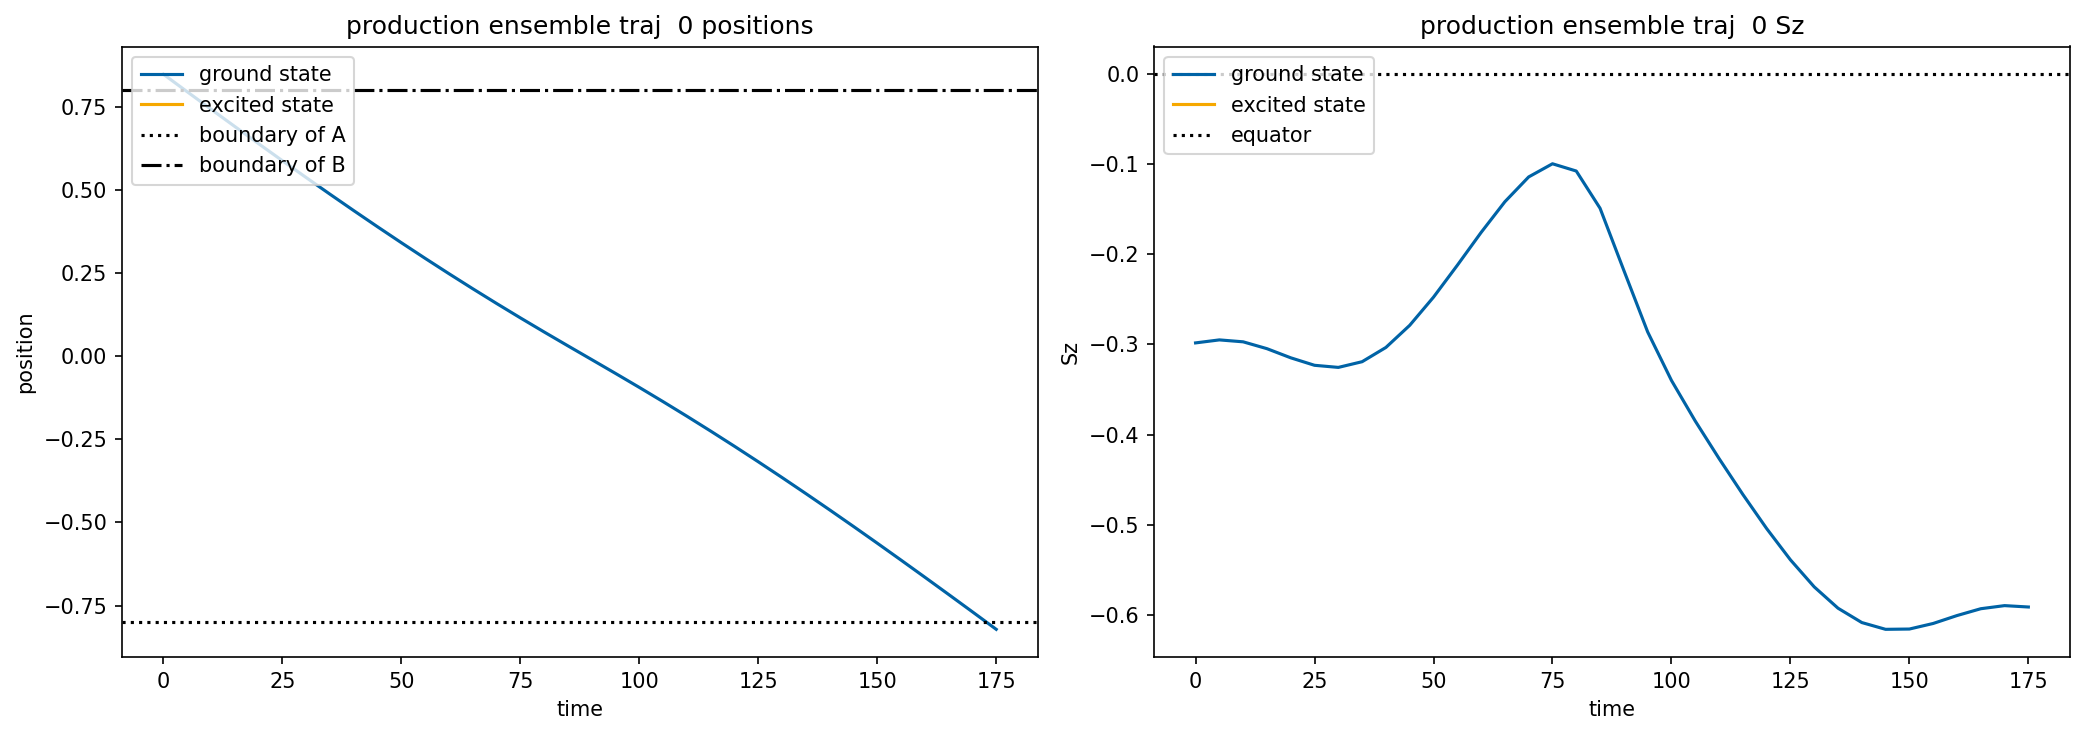

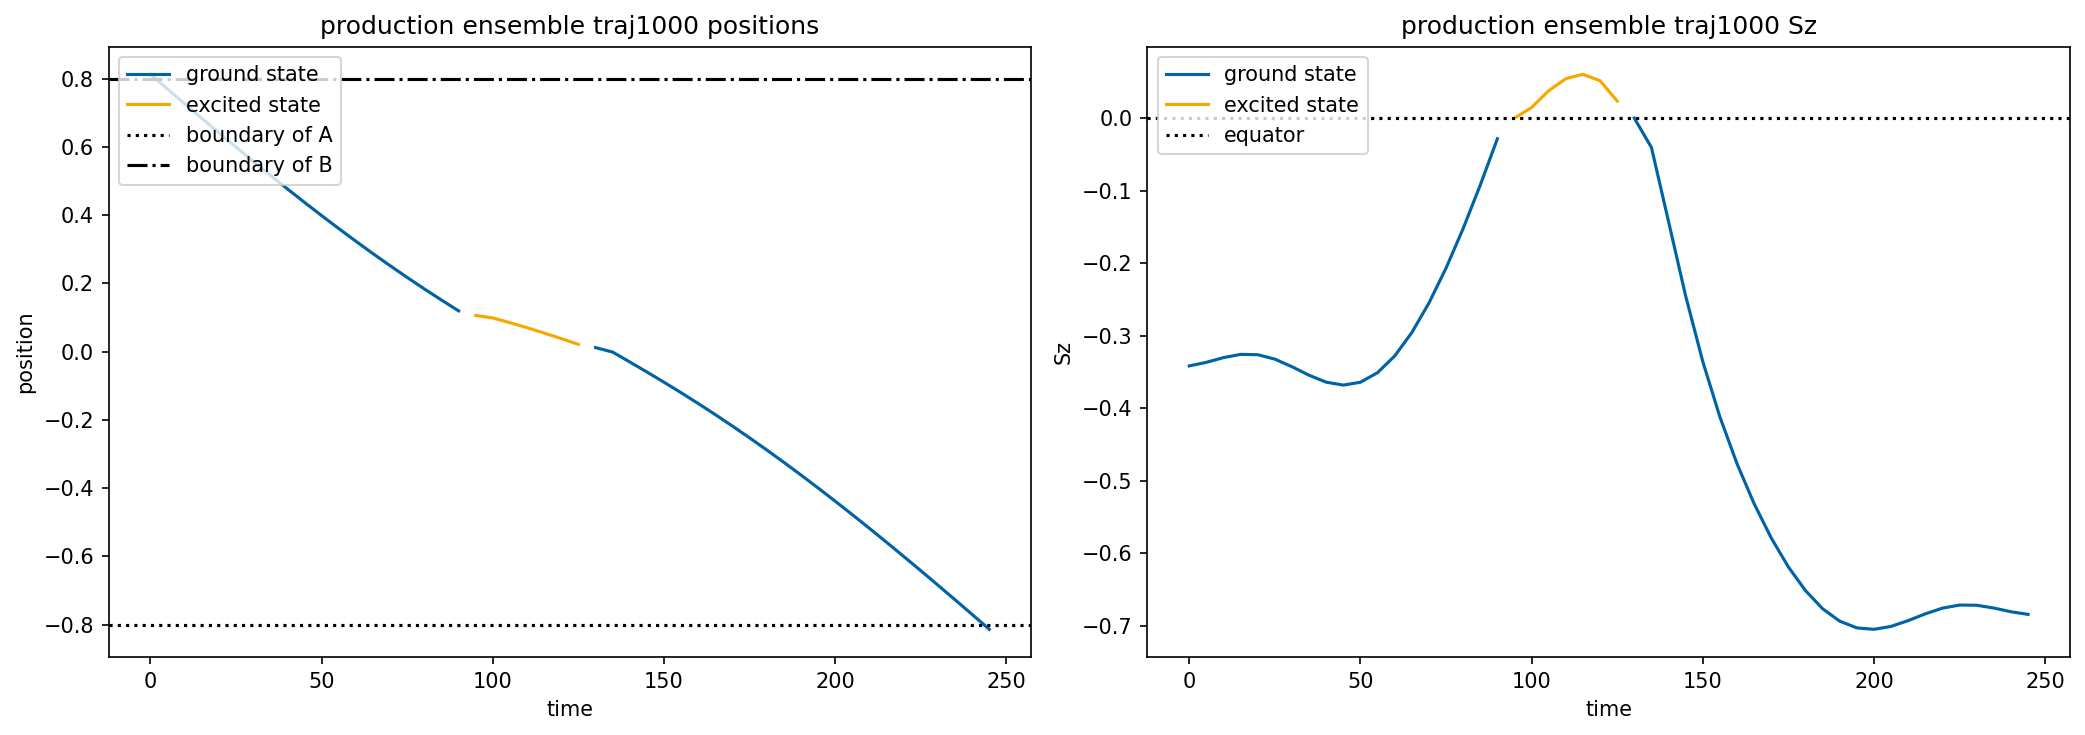

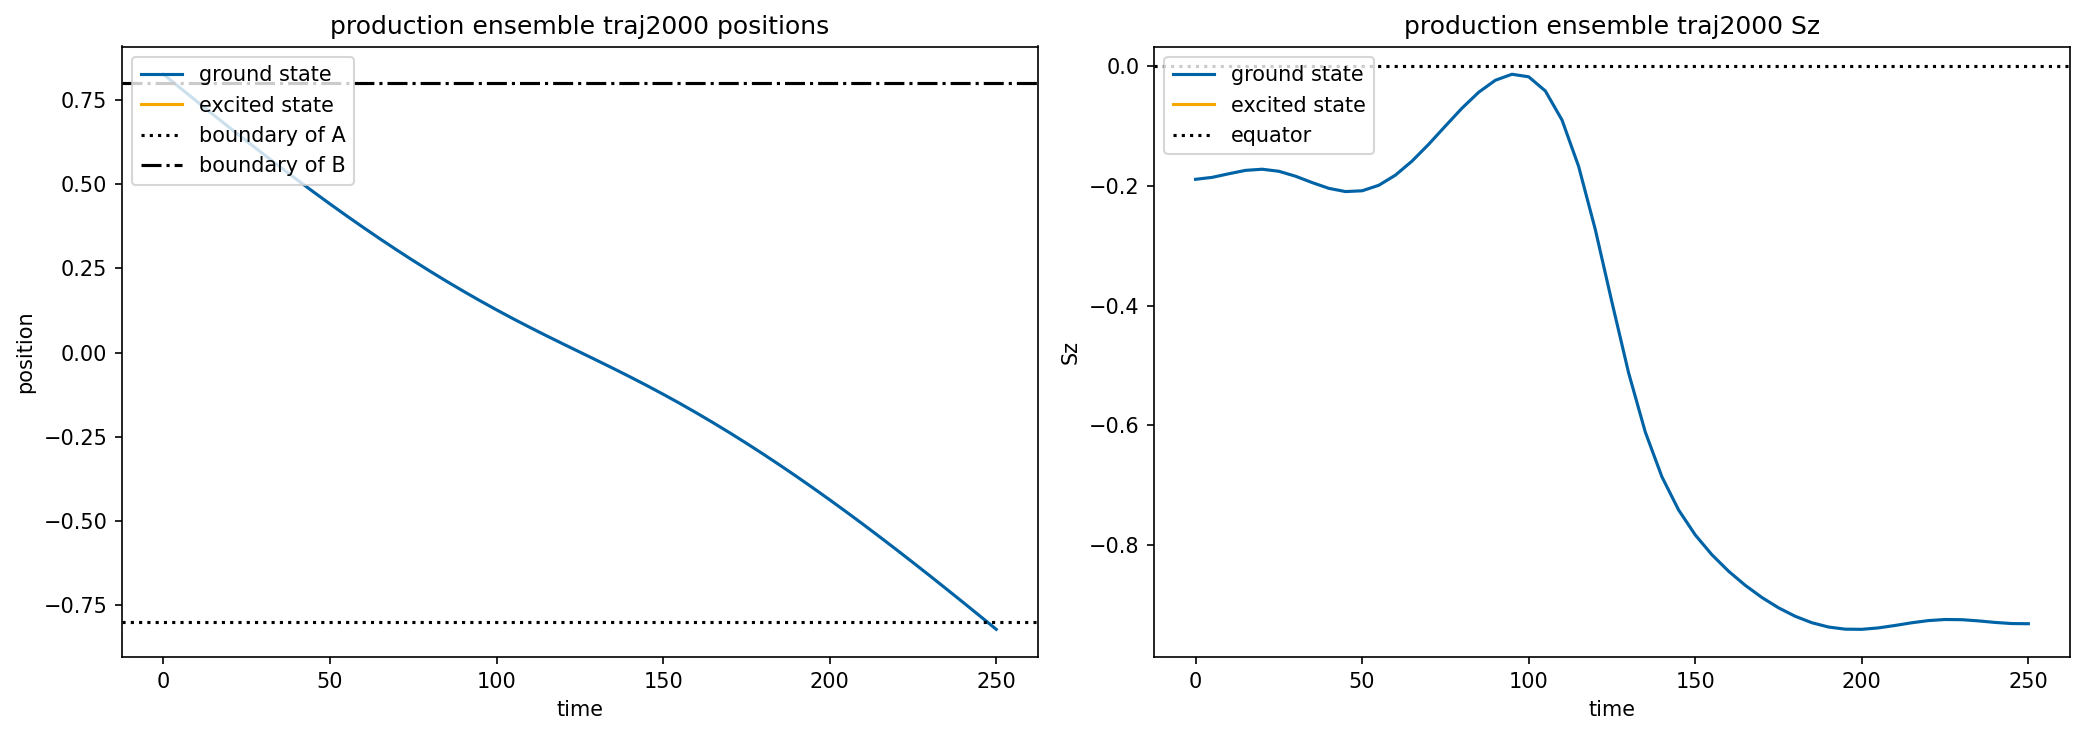

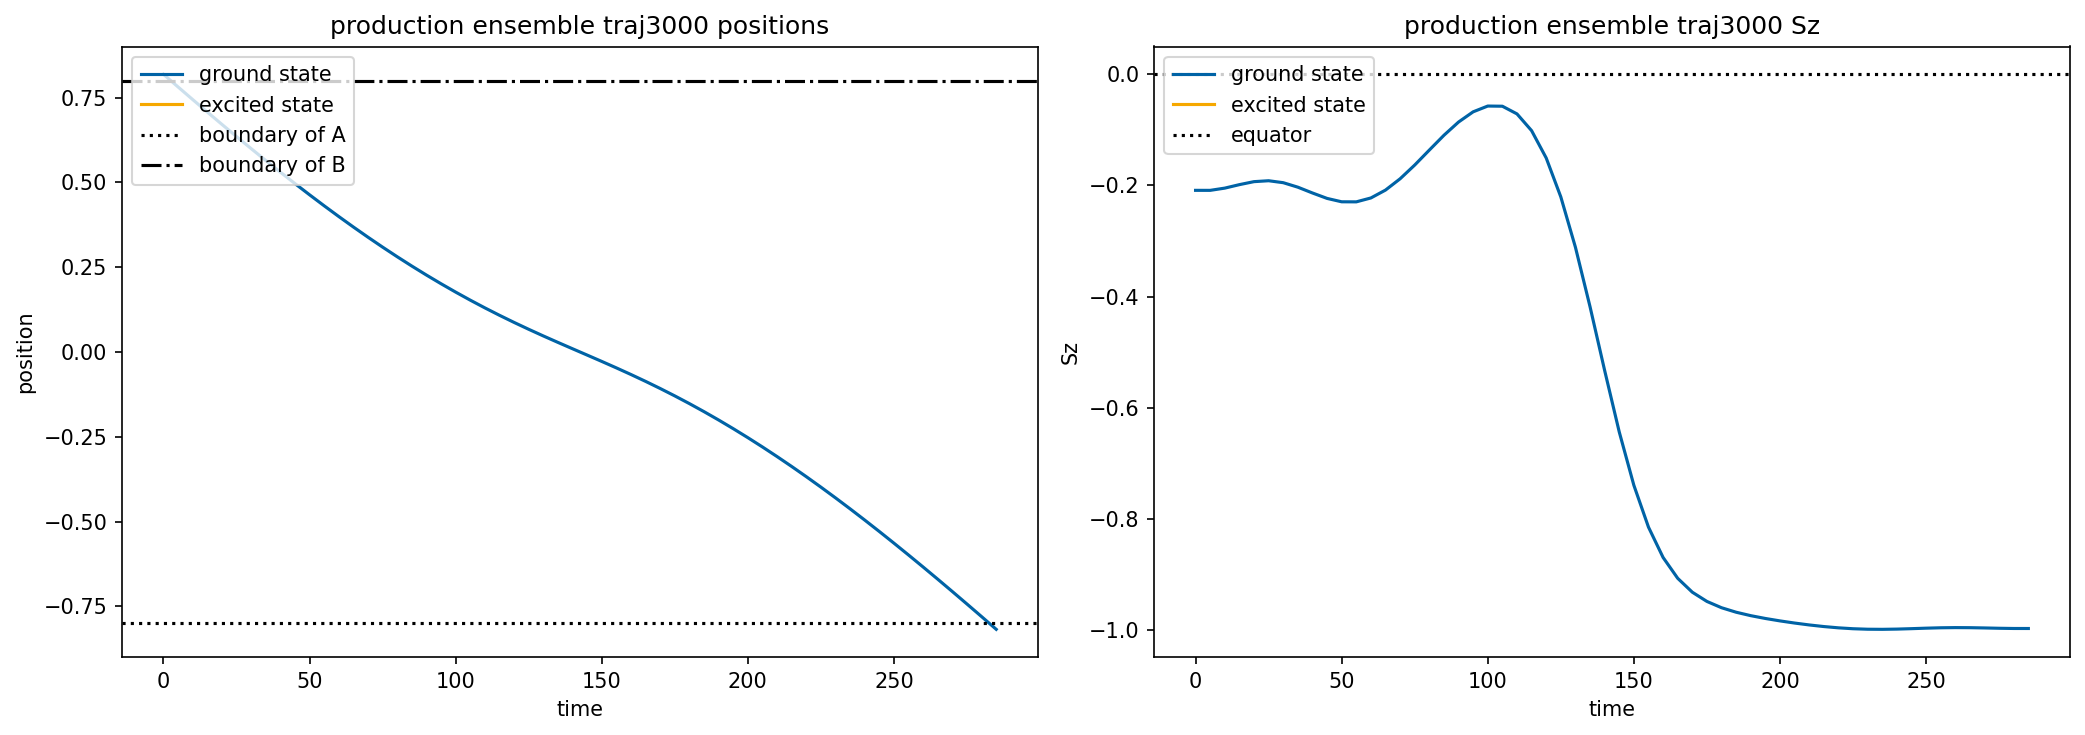

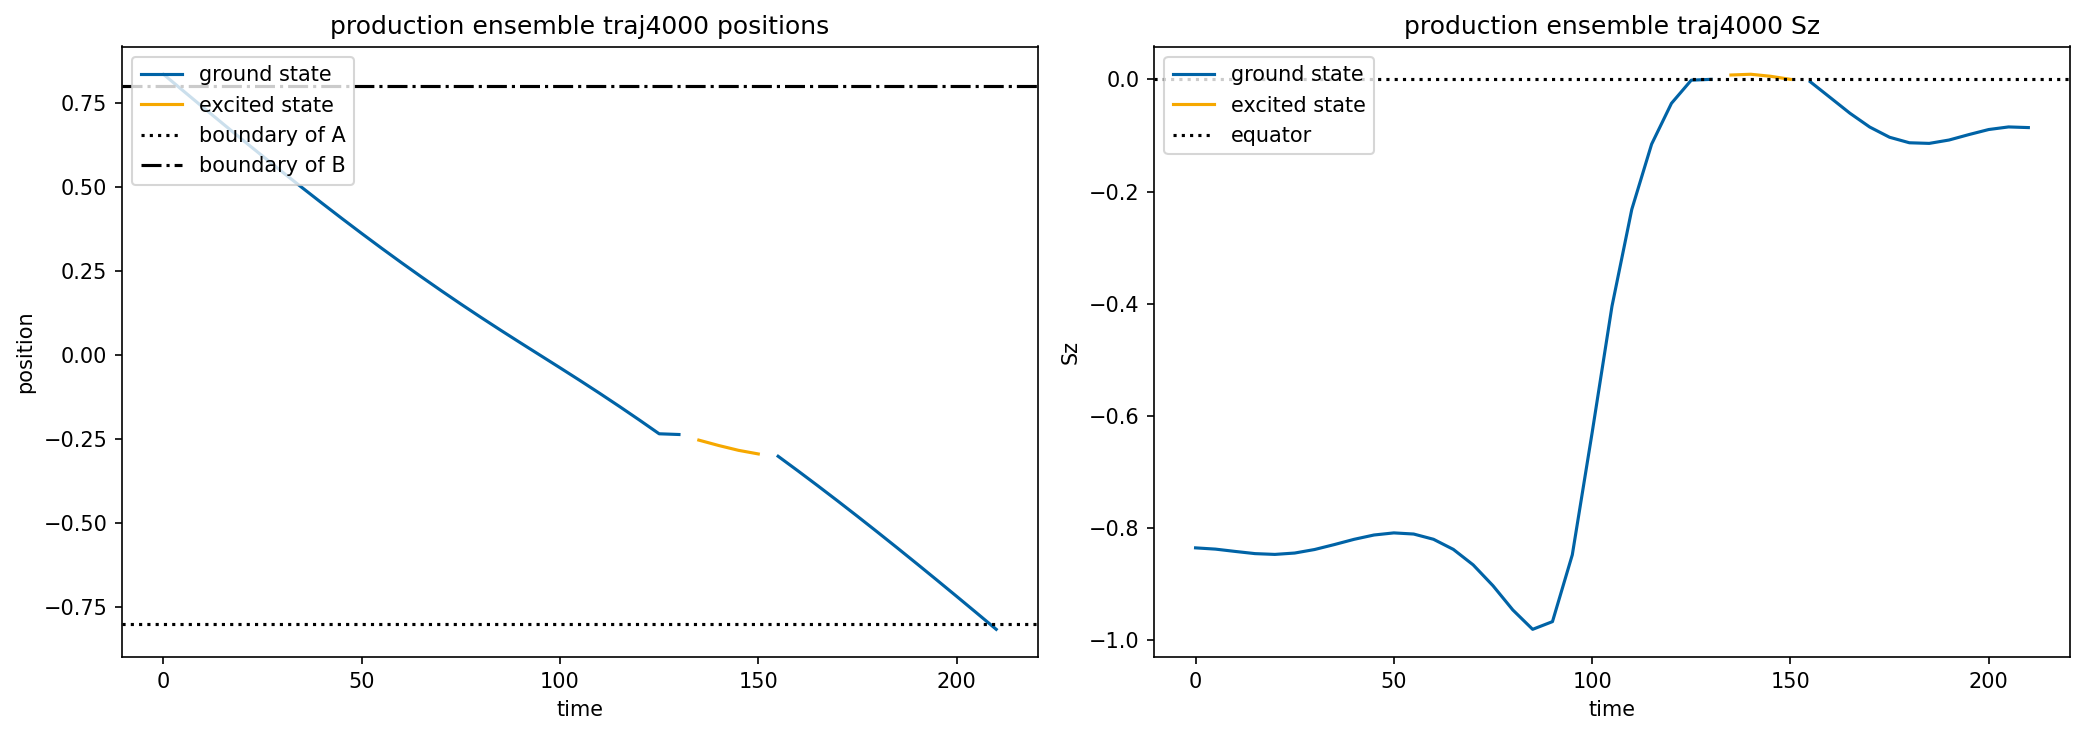

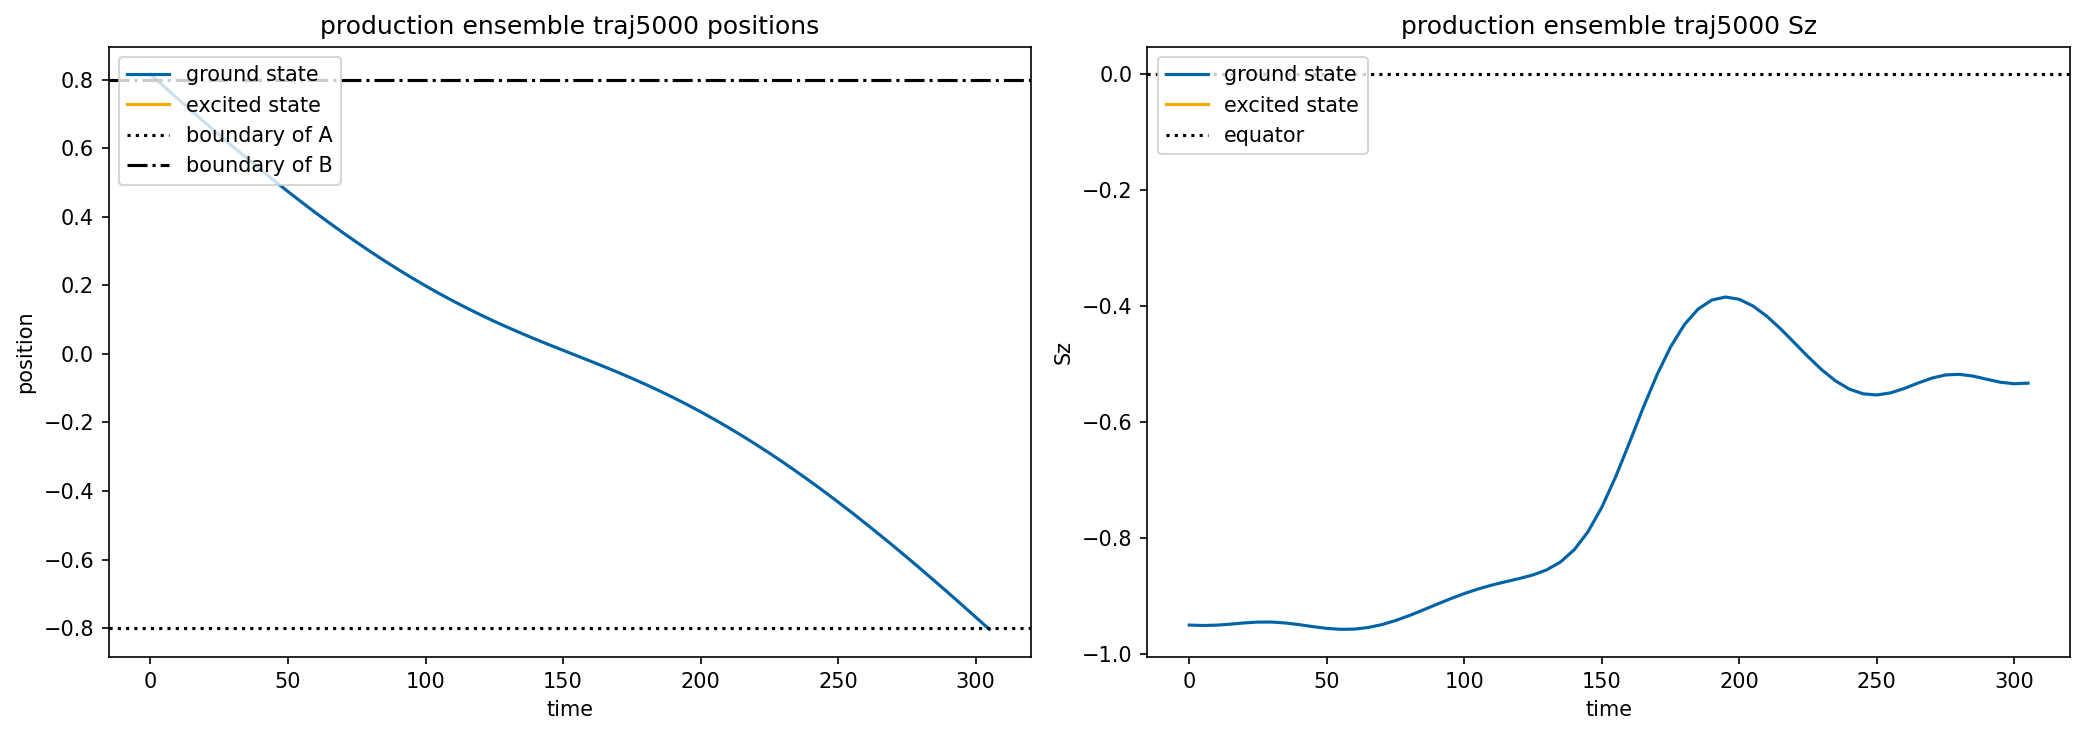

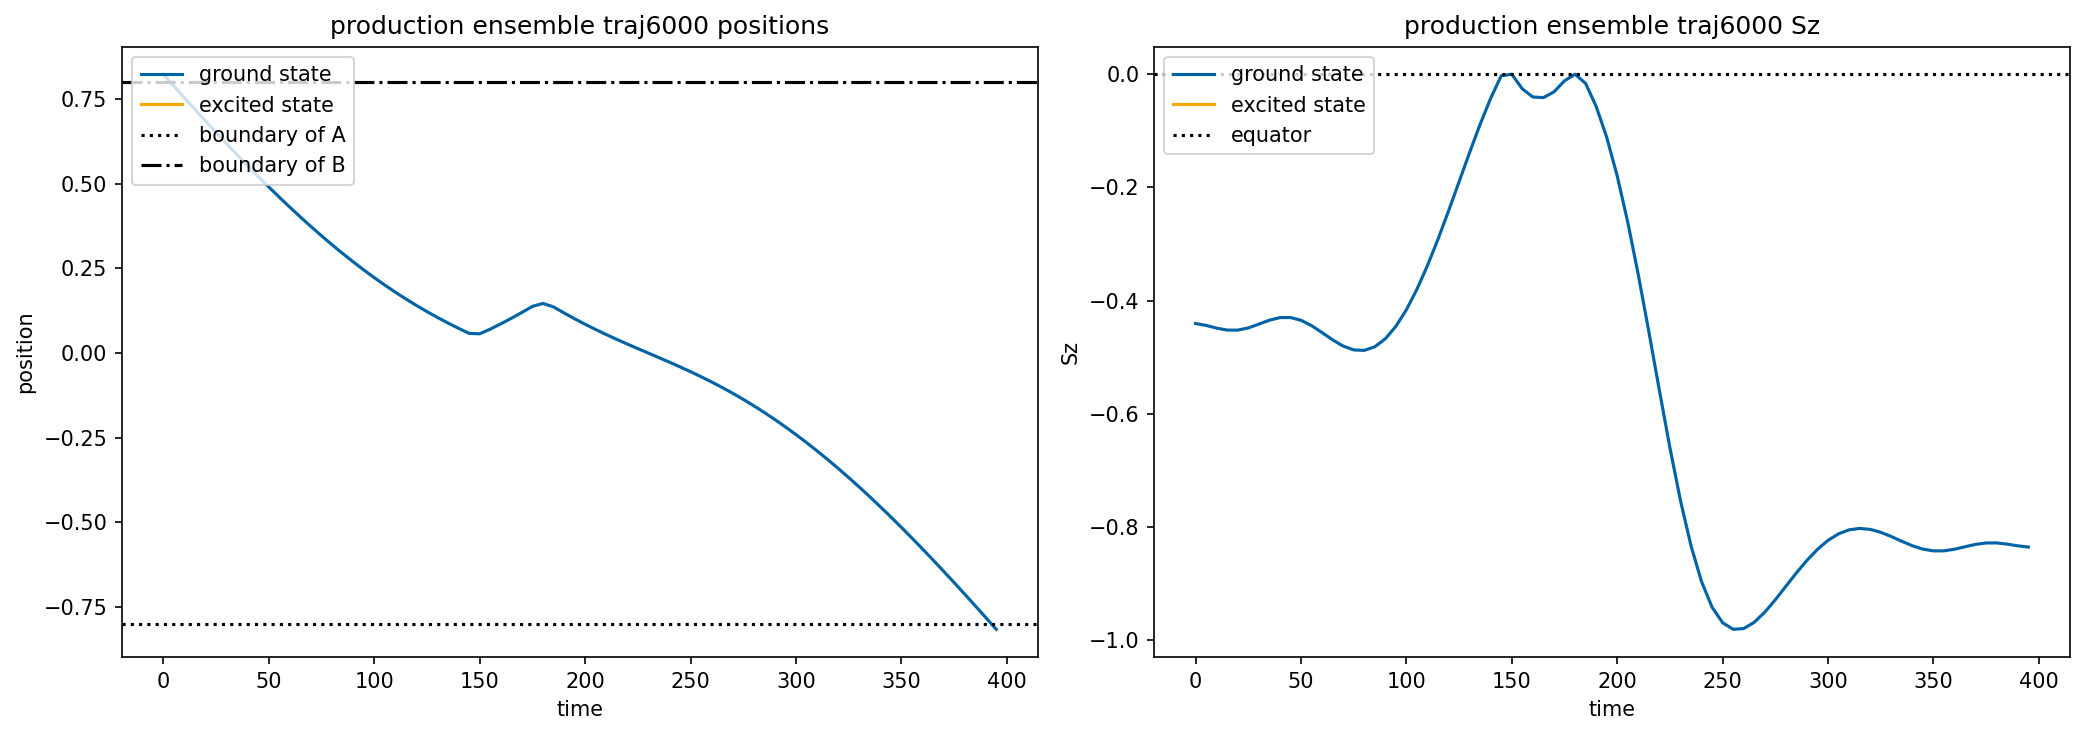

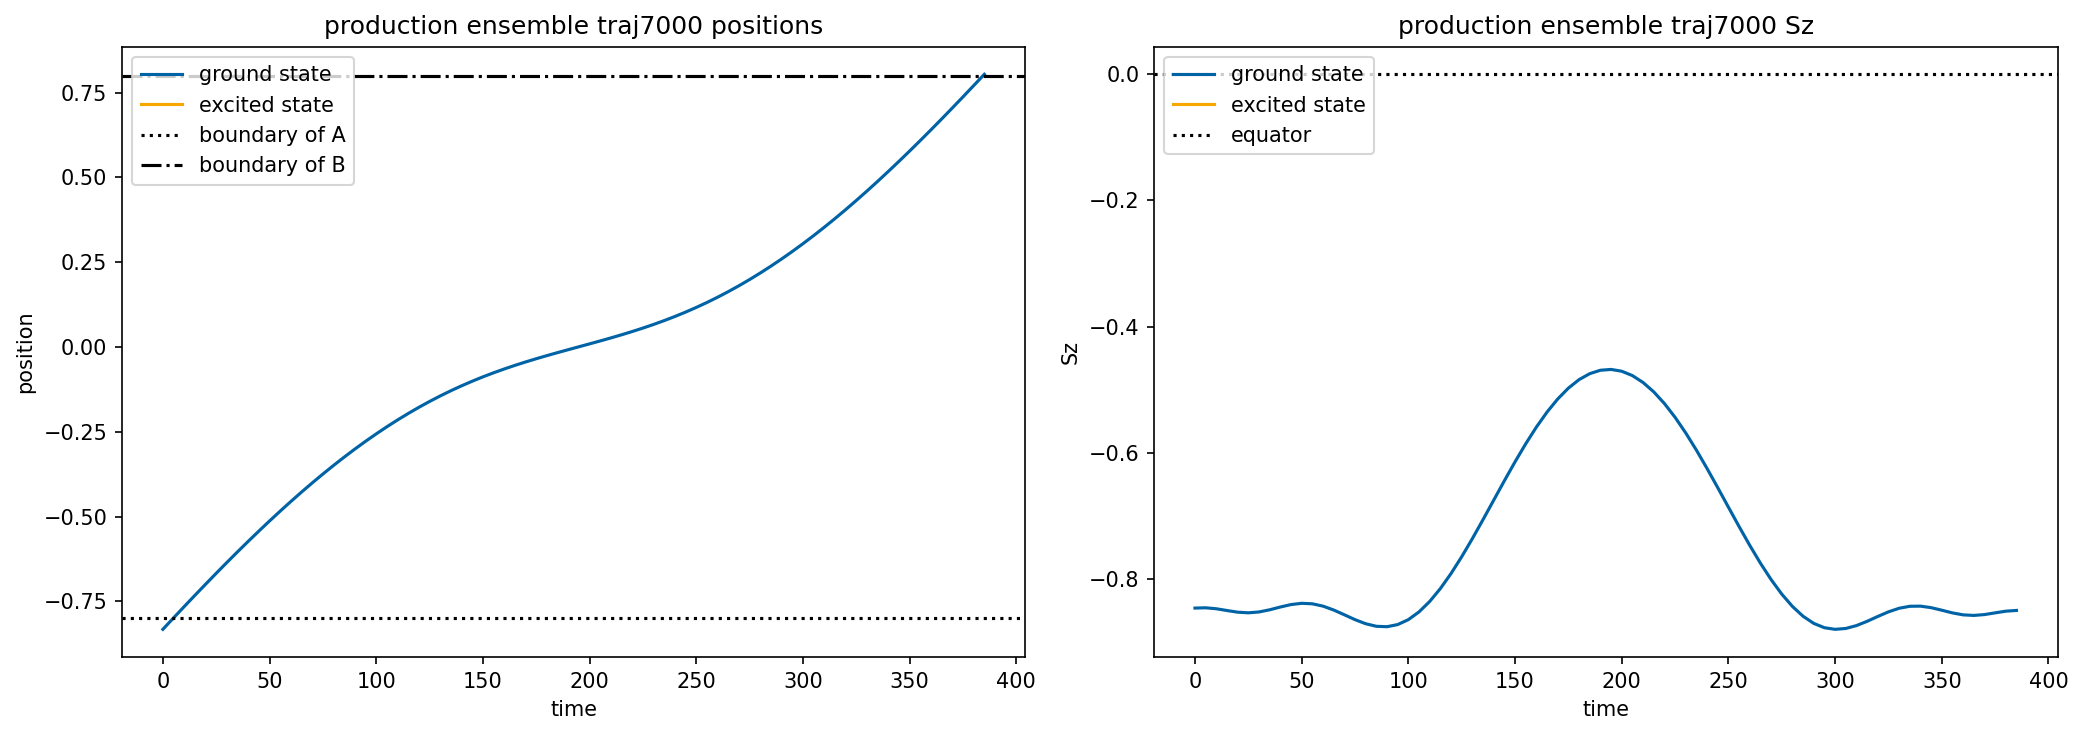

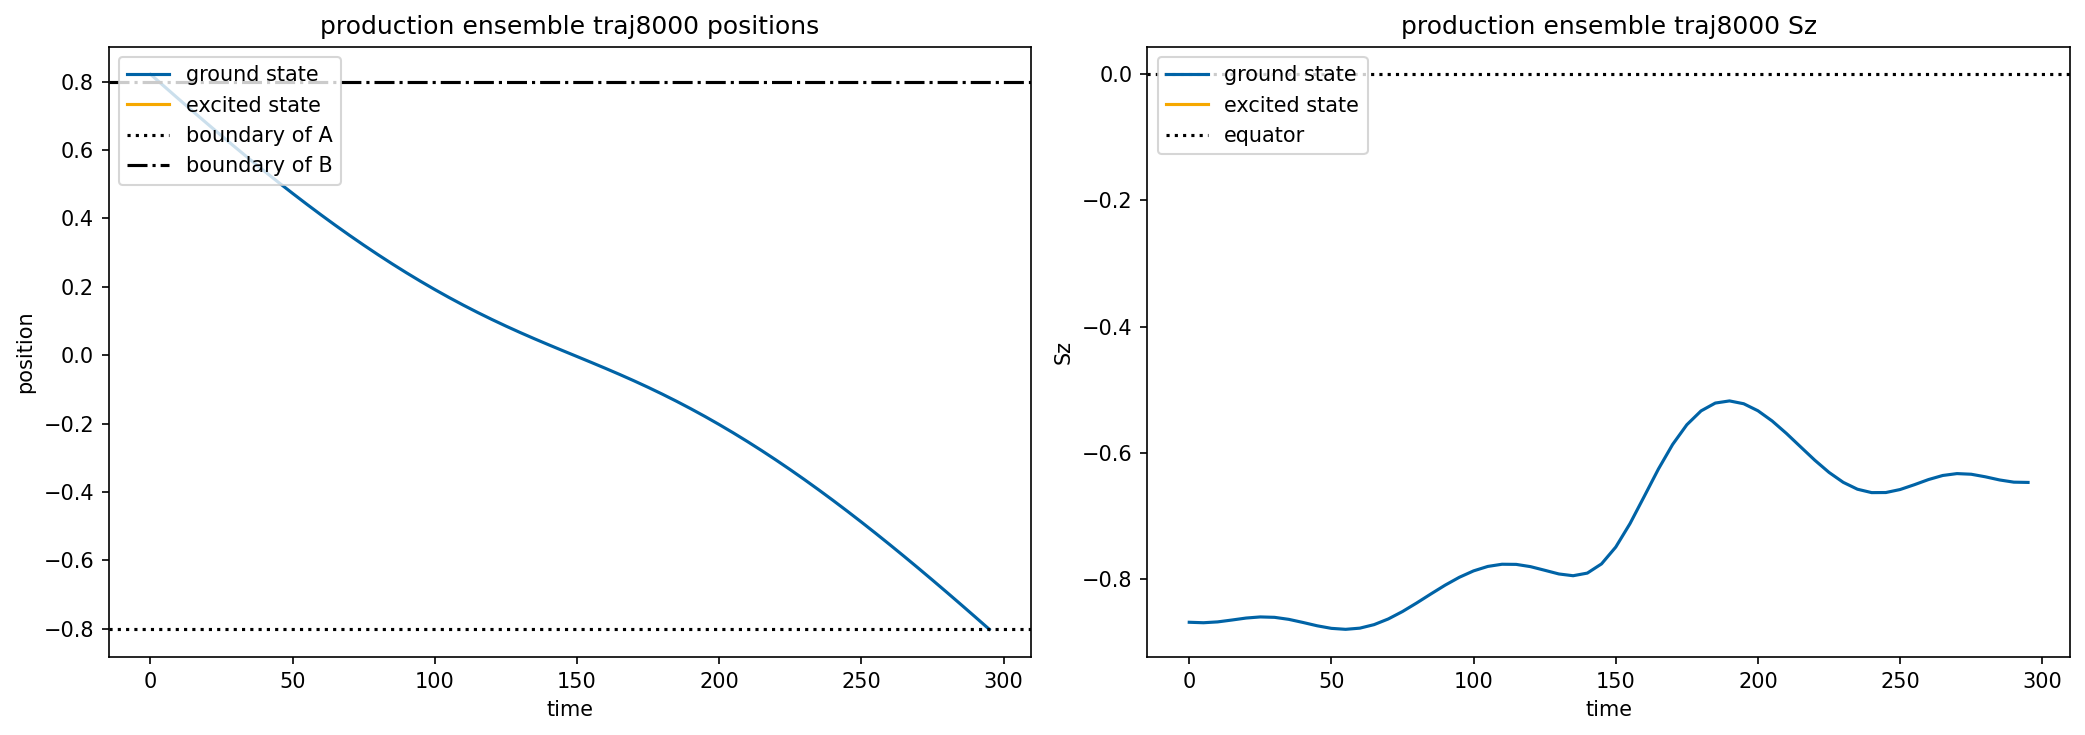

In [13]:
# Main TPS proof of concept with the selected condition Page 2: Plot some trajectories

burn_in = 0.15
discard = int(burn_in * len(tps_ensemble))
trimmed_tps_ensemble = tps_ensemble[discard:]

for k in range(0, len(trimmed_tps_ensemble), 1000):
    traj = trimmed_tps_ensemble[k]
    # --- Positions ---
    oscillator_positions = np.array([traj[i].positions for i in range(len(traj))])
    active_states = np.array([traj[i].active_state for i in range(len(traj))])
    ground_state_positions = np.copy(oscillator_positions)
    ground_state_positions[active_states > 0] = np.nan
    excited_state_positions = np.copy(oscillator_positions)
    excited_state_positions[active_states != 1] = np.nan

    # --- Coefficients ---
    oscillator_coeffs = np.array([sz_from_coeff(traj[i].coefficients) for i in range(len(traj))])
    ground_state_coeffs = np.copy(oscillator_coeffs)
    ground_state_coeffs[active_states > 0] = np.nan
    excited_state_coeffs = np.copy(oscillator_coeffs)
    excited_state_coeffs[active_states != 1] = np.nan

    # --- Create subplots ---
    fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

    # Left: Positions
    axes[0].plot(np.arange(len(traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
    axes[0].plot(np.arange(len(traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
    axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
    axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("position")
    axes[0].set_title(f"production ensemble traj{k:3d} positions")
    axes[0].legend(loc=2)

    # Right: Sz
    axes[1].plot(np.arange(len(traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
    axes[1].plot(np.arange(len(traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
    axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("Sz")
    axes[1].set_title(f"production ensemble traj{k:3d} Sz")
    axes[1].legend(loc=2)

    plt.tight_layout()
    plt.show()


In [11]:
# Main TPS proof of concept with the selected condition Page 3: number of trajectories with hop at the selected condition

traj_with_hop = 0
for k in range(0, len(trimmed_tps_ensemble)):
    traj = trimmed_tps_ensemble[k]
    # --- Positions ---
    oscillator_positions = np.array([traj[i].positions for i in range(len(traj))])
    active_states = np.array([traj[i].active_state for i in range(len(traj))])
    if np.any(active_states) == 1:
        traj_with_hop +=1
print(traj_with_hop)

2719


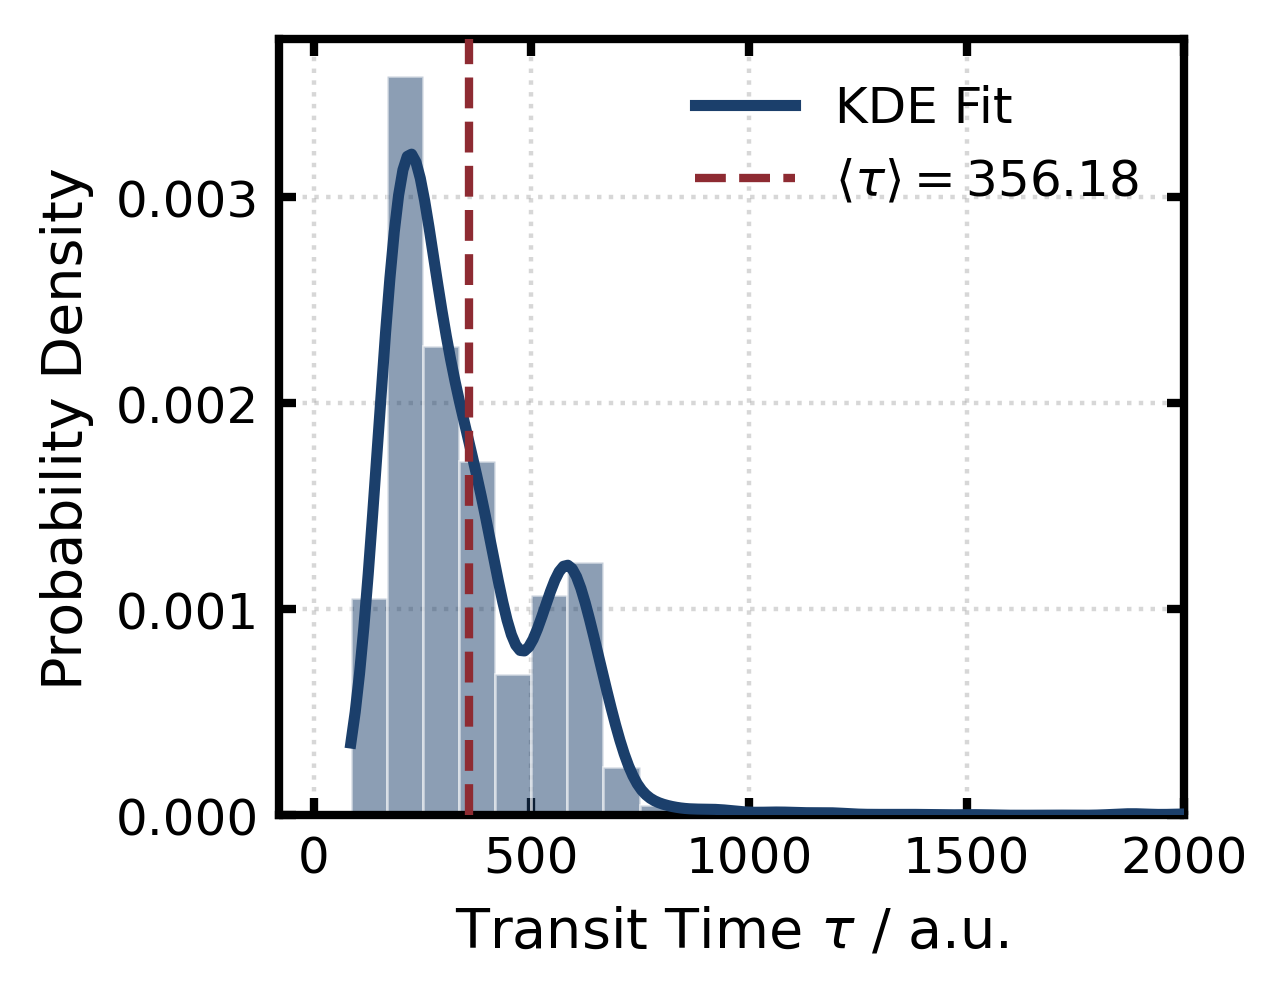

In [23]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_transit_time_dist_publish(transit_times, mean_time):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Standard single-column width (3.4 x 2.6)
    fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=400)

    # ==========================================
    # 2. PLOTTING THE DISTRIBUTION
    # ==========================================
    # The elegant, modern histogram
    ax.hist(
        transit_times,
        bins=60,
        density=True,
        color=oxford_blue,
        edgecolor='white',    # White borders separate the bins cleanly
        linewidth=0.5,
        alpha=0.5,            # Soft transparency so it doesn't overpower the KDE
        zorder=2
    )

    # The smooth KDE curve
    kde = gaussian_kde(transit_times)
    x_grid = np.linspace(min(transit_times), max(transit_times), 500)
    ax.plot(x_grid, kde(x_grid), color=oxford_blue, linewidth=2, zorder=3, label="KDE Fit")

    # The Mean Marker (Cranberry provides high contrast)
    ax.axvline(mean_time, color=cranberry, linestyle='--', linewidth=1.5, zorder=4,
               label=rf'$\langle \tau \rangle = {mean_time:.2f}$')

    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    # Journal-standard unit formatting
    ax.set_xlabel(r"Transit Time $\tau$ / a.u.", fontweight='medium')
    ax.set_ylabel("Probability Density", fontweight='medium')
    ax.set_xlim([-80,2000])

    # Grid and Ticks
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Clean, borderless legend
    ax.legend(loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig("Transit_Time_Distribution.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_transit_time_dist_publish(transit_times, mean_time)

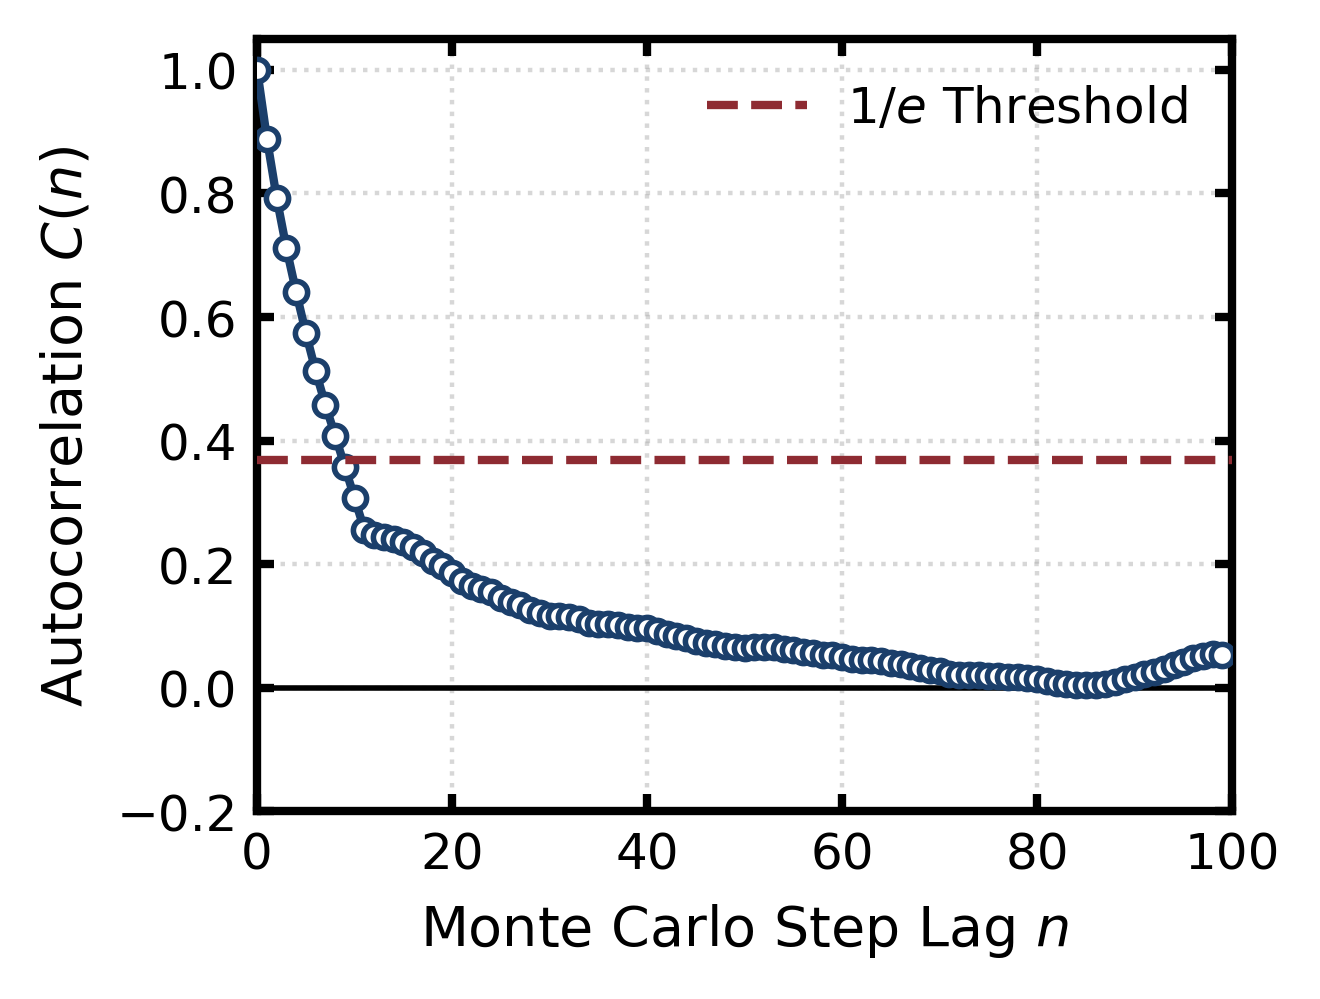

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_autocorrelation_publish(auto_correlation, max_mc_lag):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Standard single-column width (3.4 x 2.6)
    fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=400)

    # ==========================================
    # 2. PLOTTING THE AUTOCORRELATION
    # ==========================================
    # Main decay line (Winter Pine)
    # Adding white marker faces for that crisp, premium journal look
    ax.plot(range(max_mc_lag), auto_correlation, color=oxford_blue, 
            linewidth=1.5, linestyle='-', marker='o', markersize=4, 
            markerfacecolor='white', markeredgewidth=1.0, zorder=3)
    
    # y=0 baseline
    ax.axhline(0, color='black', linewidth=1.0, zorder=2)
    
    # 1/e Threshold (Cranberry)
    ax.axhline(np.exp(-1), color=cranberry, linestyle='--', linewidth=1.5, zorder=4, 
               label=r'$1/e$ Threshold')

    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    ax.set_xlabel("Monte Carlo Step Lag $n$", fontweight='medium')
    ax.set_ylabel(r"Autocorrelation $C(n)$", fontweight='medium')

    # Grid and Ticks
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Frame the data perfectly
    ax.set_xlim(0, max_mc_lag)
    # Standard limits for normalized ACF to show the peak at 1.0 and a bit of negative space
    ax.set_ylim(-0.2, 1.05) 

    # Clean, borderless legend
    ax.legend(loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig("TPS_Autocorrelation.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_autocorrelation_publish(auto_correlation, max_lag)

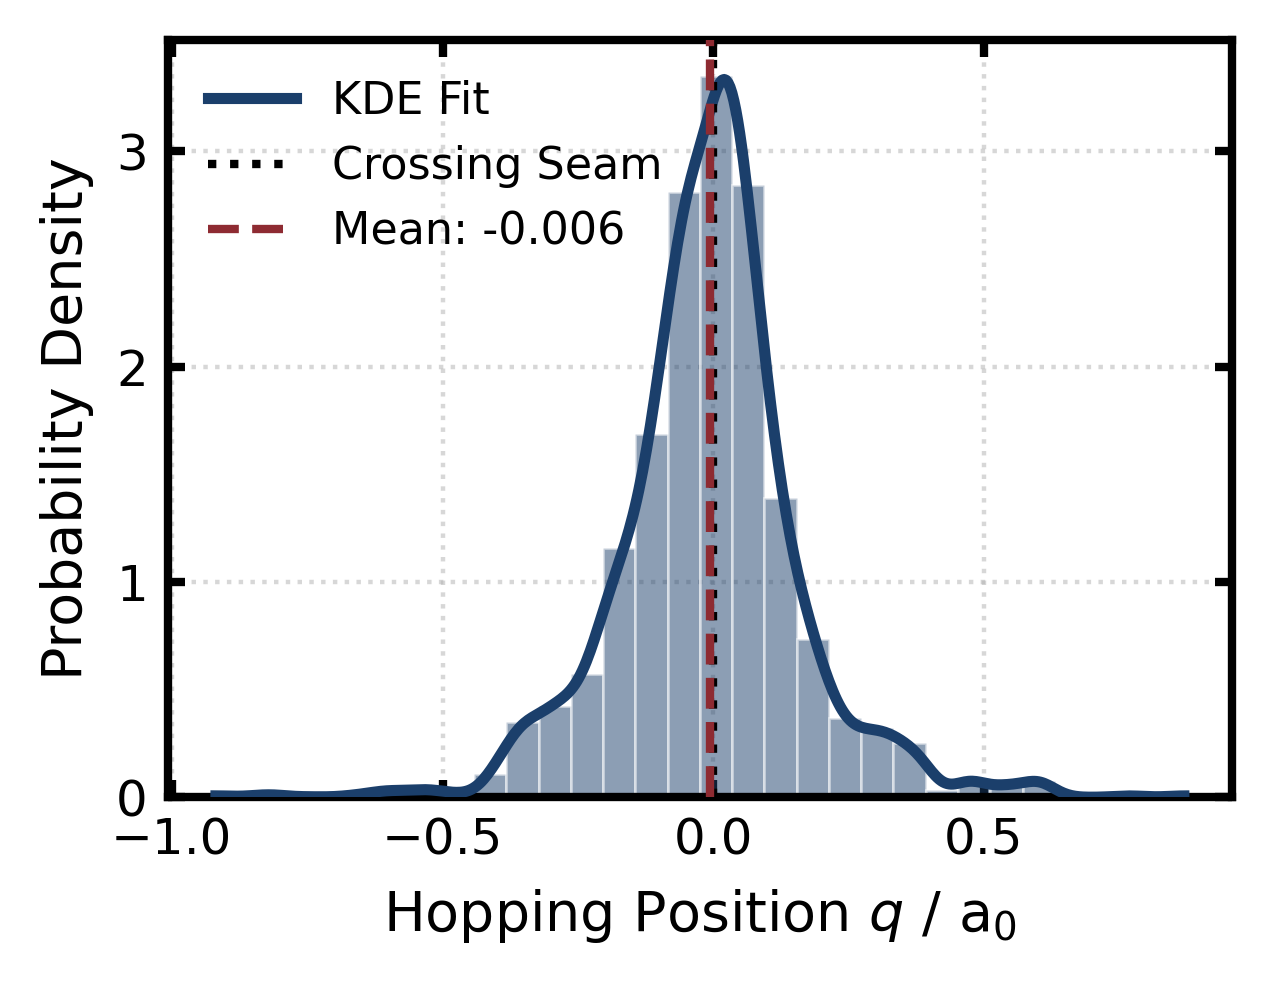

In [30]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_hopping_geometry_dist_publish(q_hops):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Standard single-column width (3.4 x 2.6)
    fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=400)

    # ==========================================
    # 2. PLOTTING THE DISTRIBUTION
    # ==========================================
    # The elegant, modern histogram in Winter Pine
    ax.hist(
        q_hops,
        bins=30,
        density=True,
        color=oxford_blue,
        edgecolor='white',    # Sharp white borders
        linewidth=0.5,
        alpha=0.5,            # Soft transparency
        zorder=2
    )

    # The smooth KDE envelope
    kde = gaussian_kde(q_hops)
    x_grid = np.linspace(min(q_hops), max(q_hops), 500)
    ax.plot(x_grid, kde(x_grid), color=oxford_blue, linewidth=2, zorder=3, label="KDE Fit")

    # The Theoretical Crossing Seam (Black dotted)
    ax.axvline(0.0, color='black', linestyle=':', linewidth=1.5, zorder=4,
               label='Crossing Seam')

    # The Calculated Mean Marker (Cranberry for high contrast)
    mean_q = np.mean(q_hops)
    ax.axvline(mean_q, color=cranberry, linestyle='--', linewidth=1.5, zorder=5,
               label=rf'Mean: {mean_q:.3f}')

    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    # Journal-standard unit formatting
    ax.set_xlabel(r"Hopping Position $q$ / a$_0$", fontweight='medium')
    ax.set_ylabel("Probability Density", fontweight='medium')

    # Grid and Ticks
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Clean, borderless legend with slightly smaller font to fit the markers
    ax.legend(loc='upper left', frameon=False, fontsize=8)

    plt.tight_layout()
    plt.savefig("Hopping_Geometry_Distribution.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_hopping_geometry_dist_publish(q_hops)

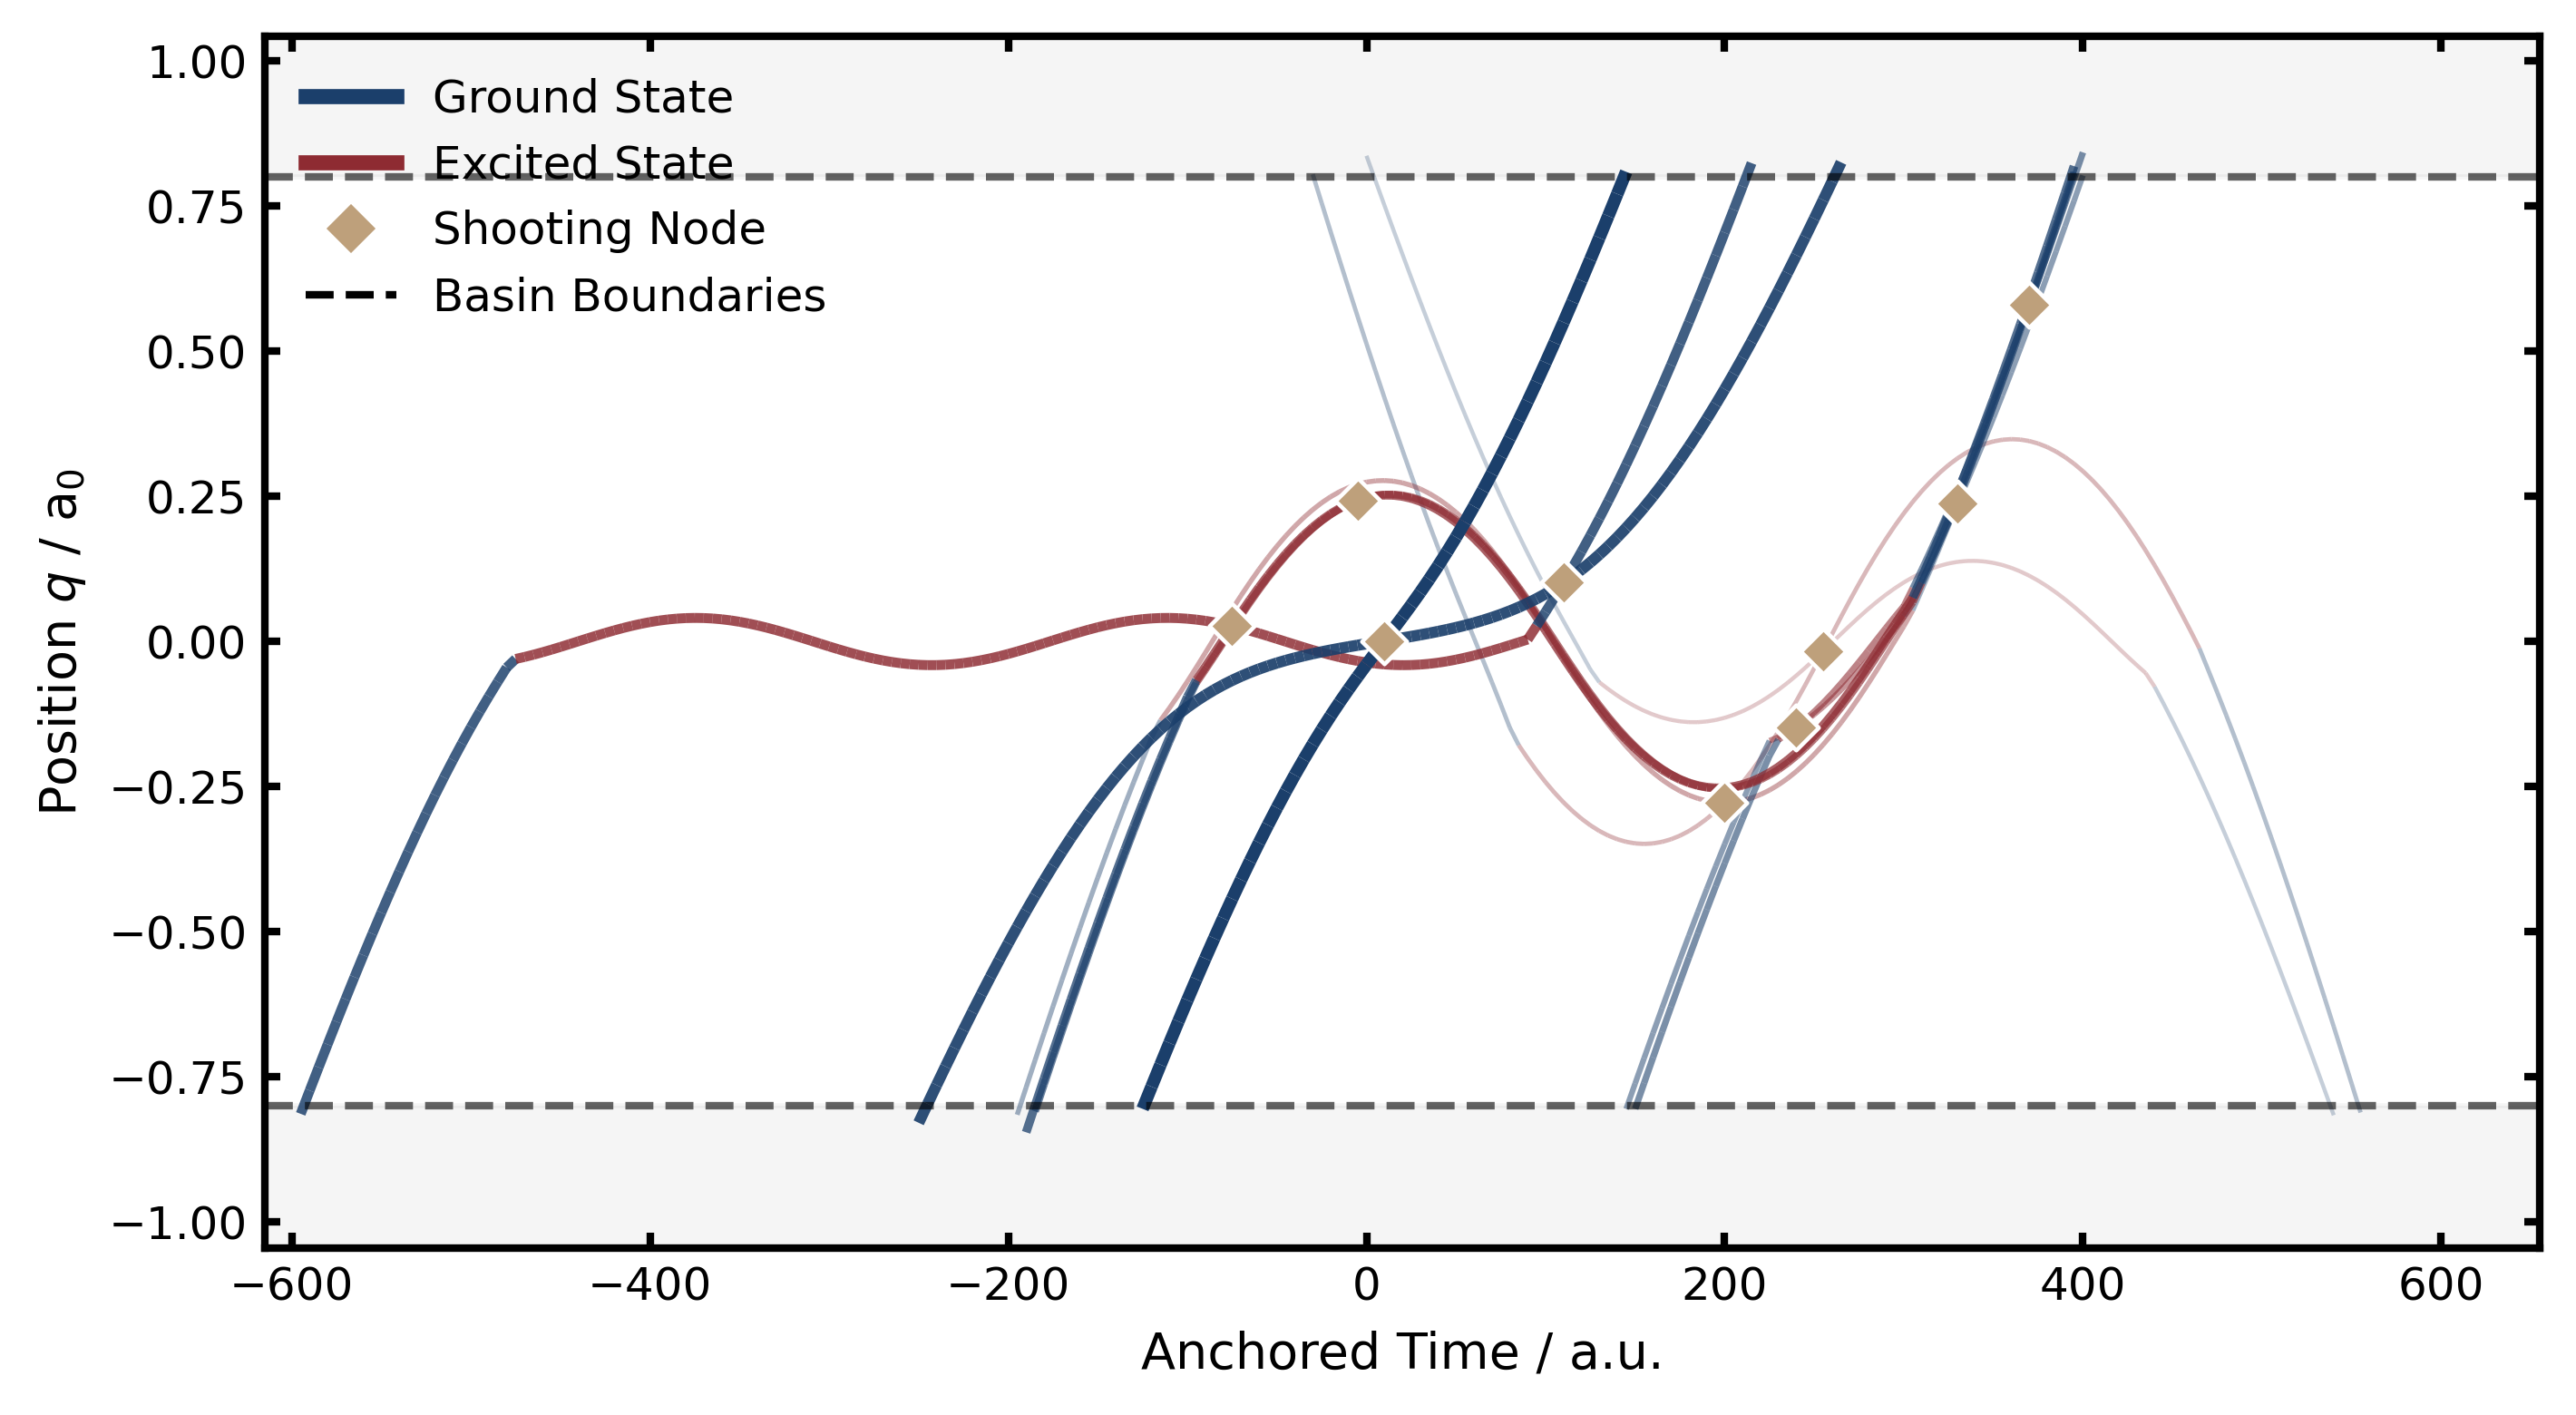

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def visualize_tps_lineage_publish(consecutive_ensemble, dt):
    """
    Plots a time-anchored TPS tree with progressive bolding and labeling,
    styled for double-column journal publication.
    """
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Double-column width (7.2), slightly taller (4.0) to give branches room to breathe
    fig, ax = plt.subplots(figsize=(7.2, 4.0), dpi=400)
    
    # Convert hex colors to RGB tuples for LineCollection
    base_0 = mcolors.to_rgb(oxford_blue)
    base_1 = mcolors.to_rgb(cranberry)

    # ==========================================
    # 2. TIME ANCHORING LOGIC (Untouched)
    # ==========================================
    time_shifts = [0.0] * len(consecutive_ensemble)
    q_min, q_max = float('inf'), float('-inf')
    
    for i in range(1, len(consecutive_ensemble)):
        grid_curr = [s for s in consecutive_ensemble[i] if s.is_grid]
        grid_prev = [s for s in consecutive_ensemble[i-1] if s.is_grid]
        shoot_idx_curr = next((idx for idx, s in enumerate(grid_curr) if getattr(s, 'shooting', False)), None)
        
        if shoot_idx_curr is not None:
            q_shoot = grid_curr[shoot_idx_curr].positions
            distances = [abs(s.positions - q_shoot) for s in grid_prev]
            shoot_idx_prev = np.argmin(distances)
            time_shifts[i] = (shoot_idx_prev * dt + time_shifts[i-1]) - (shoot_idx_curr * dt)
        else:
            time_shifts[i] = time_shifts[i-1]

    # ==========================================
    # 3. PLOTTING THE LINEAGE TREE
    # ==========================================
    max_absolute_time = 0
    N = len(consecutive_ensemble)
    
    for i, traj in enumerate(consecutive_ensemble):
        grid_traj = [s for s in traj if s.is_grid]
        times = np.arange(len(grid_traj)) * dt + time_shifts[i]
        positions = [s.positions for s in grid_traj]
        states = [s.active_state for s in grid_traj]
        
        q_min, q_max = min(q_min, min(positions)), max(q_max, max(positions))
        max_absolute_time = max(max_absolute_time, max(times))

        # Scale down linewidths for print resolution (0.8 to 2.5)
        lw = 0.8 + 1.7 * (i / (N - 1 if N > 1 else 1))**1.5 
        alpha = 0.25 + 0.75 * (i / (N - 1 if N > 1 else 1))
        
        points = np.array([times, positions]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        colors = [base_0 if state == 0 else base_1 for state in states[:-1]]
        
        lc = LineCollection(segments, colors=colors, alpha=alpha, linewidths=lw)
        ax.add_collection(lc)
        
        # Shooting nodes: scaled down to size 40, colored golden
        for j, snap in enumerate(grid_traj):
            if getattr(snap, 'shooting', False) is True:
                ax.scatter(times[j], positions[j], color=golden, 
                           edgecolor='white', marker='D', s=40, zorder=10, linewidth=0.8)

    # ==========================================
    # 4. BASIN BOUNDARIES & AESTHETICS
    # ==========================================
    ax.axhline(y=-0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axhline(y=0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Faint shading for the stable basins
    ax.fill_between([min(time_shifts)-50, max_absolute_time+150], -2.5, -0.8, color='gray', alpha=0.08, zorder=0)
    ax.fill_between([min(time_shifts)-50, max_absolute_time+150], 0.8, 2.5, color='gray', alpha=0.08, zorder=0)
    
    # Journal-standard axis labels
    ax.set_xlabel("Anchored Time / a.u.", fontweight='medium')
    ax.set_ylabel("Position $q$ / a$_0$", fontweight='medium')
    
    # Custom Legend
    legend_elements = [
        Line2D([0], [0], color=oxford_blue, lw=3, label='Ground State'),
        Line2D([0], [0], color=cranberry, lw=3, label='Excited State'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor=golden, 
               markeredgecolor='white', markersize=8, label='Shooting Node'),
        Line2D([0], [0], color='black', ls='--', lw=1.5, label='Basin Boundaries')
    ]
    ax.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=9)
    
    # Perfect framing
    ax.set_xlim(min(time_shifts) - 20, max_absolute_time + 100)
    ax.set_ylim(q_min - 0.2, q_max + 0.2)
    
    # Thick boundaries and inward ticks
    ax.tick_params(direction='in', top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.savefig("TPS_Lineage_Tree.png", dpi=400, bbox_inches='tight')
    plt.show()

unique_succession = []
for traj in trimmed_tps_ensemble:
    if not unique_succession or traj is not unique_succession[-1]:
        unique_succession.append(traj)

unique_succession = unique_succession[610:620]

# Run it:
visualize_tps_lineage_publish(unique_succession, dt=dt)

In [ ]:
# Temperature speed up evaluation
# For reproduction: do not forget to generate the seed trajectory.

ensemble_size = 10000
max_traj_length = 5000

temperature_range = [1263.0, 2105.0, 2526.0, 3158.0, 4210.0]
speedup_list = []

for temp in temperature_range:
    tps_selector = UniformShootingSelector(temp=temp, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9)
    path_sampling = PathSampling(selector=tps_selector, seed_traj=seed_traj, max_iter=ensemble_size,
                                max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)
    engine_builder = MASHEngine
    tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)
    MC_rate = path_sampling.MC_acceptance()
    speedup = path_sampling.efficiency_statistics(naive_tps_ensemble=naive_tps_ensemble, mc_rate=MC_rate)
    speedup_list.append(speedup)

print([(tem, spd) for tem, spd in zip(temperature_range, speedup_list)])

--- TPS Iteration 0 ---
Rejected
--- TPS Iteration 1 ---
Rejected
--- TPS Iteration 2 ---
Rejected
--- TPS Iteration 3 ---
Rejected
--- TPS Iteration 4 ---
Rejected
--- TPS Iteration 5 ---
Accepted
--- TPS Iteration 6 ---
Accepted
--- TPS Iteration 7 ---
Accepted
--- TPS Iteration 8 ---
Rejected
--- TPS Iteration 9 ---
Rejected
--- TPS Iteration 10 ---
Accepted
--- TPS Iteration 11 ---
Accepted
--- TPS Iteration 12 ---
Rejected
--- TPS Iteration 13 ---
Accepted
--- TPS Iteration 14 ---
Rejected
--- TPS Iteration 15 ---
Accepted
--- TPS Iteration 16 ---
Accepted
--- TPS Iteration 17 ---
Rejected
--- TPS Iteration 18 ---
Rejected
--- TPS Iteration 19 ---
Rejected
--- TPS Iteration 20 ---
Rejected
--- TPS Iteration 21 ---
Rejected
--- TPS Iteration 22 ---
Accepted
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Accepted
--- TPS Iteration 25 ---
Accepted
--- TPS Iteration 26 ---
Rejected
--- TPS Iteration 27 ---
Accepted
--- TPS Iteration 28 ---
Accepted
--- TPS Iteration 29 ---

--- TPS Iteration 0 ---
Accepted
--- TPS Iteration 1 ---
Rejected
--- TPS Iteration 2 ---
Rejected
--- TPS Iteration 3 ---
Accepted
--- TPS Iteration 4 ---
Rejected
--- TPS Iteration 5 ---
Rejected
--- TPS Iteration 6 ---
Rejected
--- TPS Iteration 7 ---
Rejected
--- TPS Iteration 8 ---
Accepted
--- TPS Iteration 9 ---
Accepted
--- TPS Iteration 10 ---
Accepted
--- TPS Iteration 11 ---
Accepted
--- TPS Iteration 12 ---
Rejected
--- TPS Iteration 13 ---
Accepted
--- TPS Iteration 14 ---
Rejected
--- TPS Iteration 15 ---
Rejected
--- TPS Iteration 16 ---
Rejected
--- TPS Iteration 17 ---
Rejected
--- TPS Iteration 18 ---
Rejected
--- TPS Iteration 19 ---
Accepted
--- TPS Iteration 20 ---
Rejected
--- TPS Iteration 21 ---
Accepted
--- TPS Iteration 22 ---
Accepted
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Accepted
--- TPS Iteration 25 ---
Rejected
--- TPS Iteration 26 ---
Rejected
--- TPS Iteration 27 ---
Rejected
--- TPS Iteration 28 ---
Rejected
--- TPS Iteration 29 ---

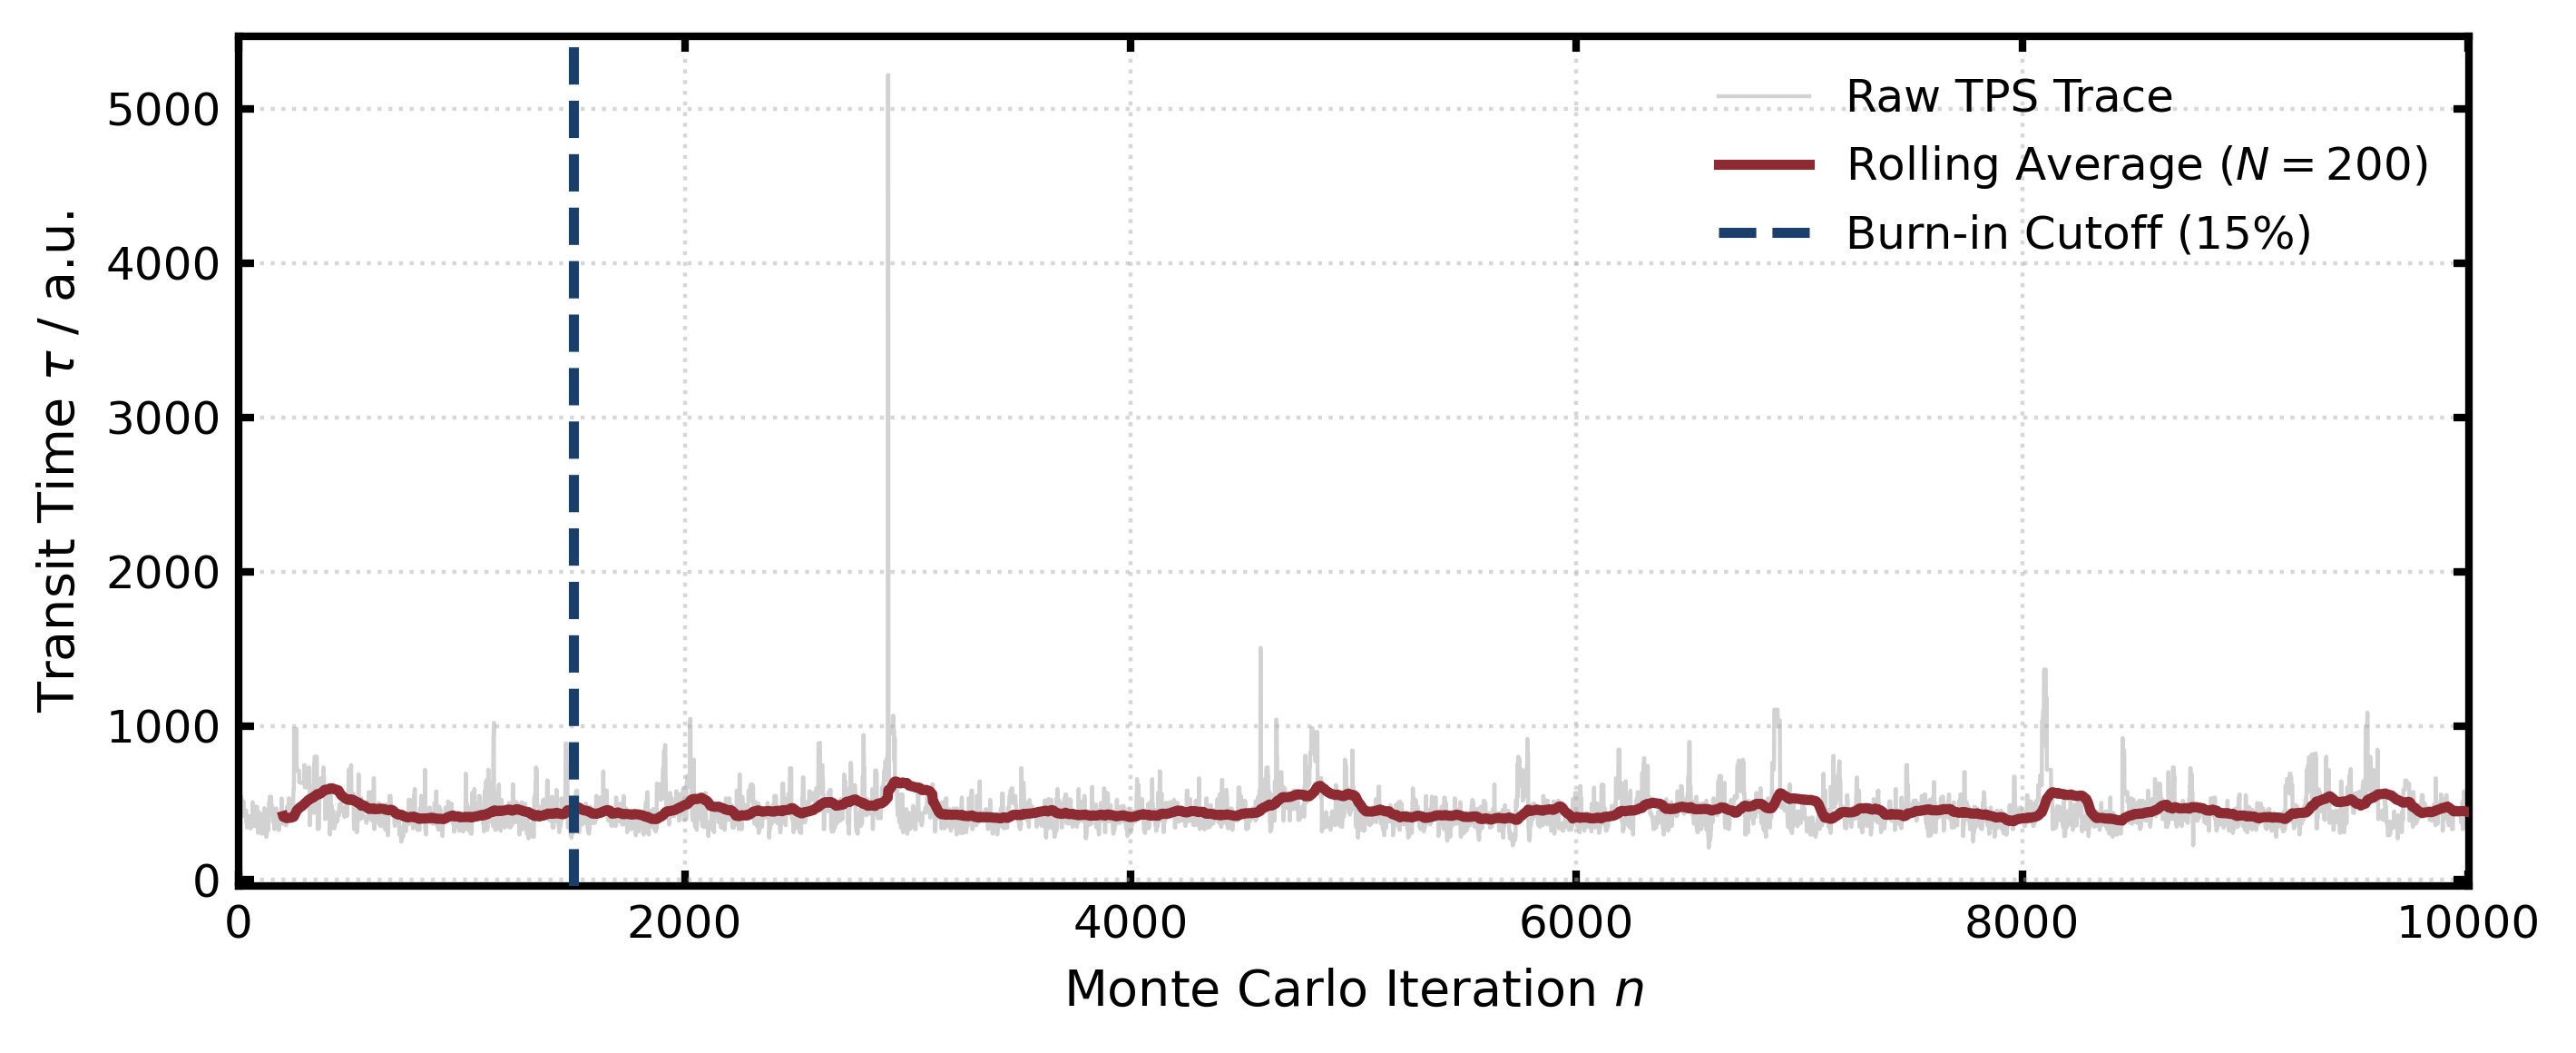

In [61]:
# Equilibration studies: 1000K

ensemble_size = 10000
max_traj_length = 5000

tps_selector = UniformShootingSelector(temp=1000, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9)
path_sampling = PathSampling(selector=tps_selector, seed_traj=seed_traj, max_iter=ensemble_size,
                             max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)

engine_builder = MASHEngine
tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)
MC_rate = path_sampling.MC_acceptance()

import matplotlib.pyplot as plt
import numpy as np

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def verify_equilibration_publish(tps_ensemble, dt, temp, burn_in_fraction=0.15, window_size=200):
    """
    Plots a highly polished MCMC trace of transit times to visually 
    verify the burn-in period and chain equilibration.
    """
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Double-column width, relatively short to emphasize the horizontal time evolution
    fig, ax = plt.subplots(figsize=(7.2, 3.0), dpi=400)

    # ==========================================
    # 2. DATA PROCESSING (Untouched)
    # ==========================================
    transit_times = []
    for traj in tps_ensemble:
        grid_snaps = [s for s in traj if s.is_grid]
        transit_times.append((len(grid_snaps) - 1) * dt)
        
    transit_times = np.array(transit_times)
    iterations = np.arange(len(transit_times))
    
    kernel = np.ones(window_size) / window_size
    rolling_mean = np.convolve(transit_times, kernel, mode='valid')
    rolling_iters = iterations[window_size - 1:]

    # ==========================================
    # 3. PLOTTING
    # ==========================================
    # Raw trace (faint gray so it provides texture without overwhelming the plot)
    ax.plot(iterations, transit_times, color='gray', alpha=0.35, linewidth=0.8, 
            zorder=1, label='Raw TPS Trace')
    
    # Smoothed trace (Bold Cranberry)
    ax.plot(rolling_iters, rolling_mean, color=cranberry, linewidth=2.0, 
            zorder=3, label=f'Rolling Average ($N={window_size}$)')
    
    # Burn-in Cutoff (Oxford Blue)
    assumed_burn_in = int(len(tps_ensemble) * burn_in_fraction)
    ax.axvline(x=assumed_burn_in, color=oxford_blue, linestyle='--', linewidth=2.0, 
               zorder=4, label=f'Burn-in Cutoff ({int(burn_in_fraction*100)}%)')

    # ==========================================
    # 4. LABELS & FORMATTING
    # ==========================================
    ax.set_xlabel("Monte Carlo Iteration $n$", fontweight='medium')
    ax.set_ylabel(r"Transit Time $\tau$ / a.u.", fontweight='medium')
    
    # Tight bounds to eliminate floating white space on the x-axis
    ax.set_xlim(0, len(iterations))
    
    # Inward ticks and clean grid
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Minimalist legend, placed in the top right to usually avoid the bulk of the data
    ax.legend(loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(f"MCMC_Equilibration_T{temp}K.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
verify_equilibration_publish(tps_ensemble=tps_ensemble, dt=dt, temp=1000)

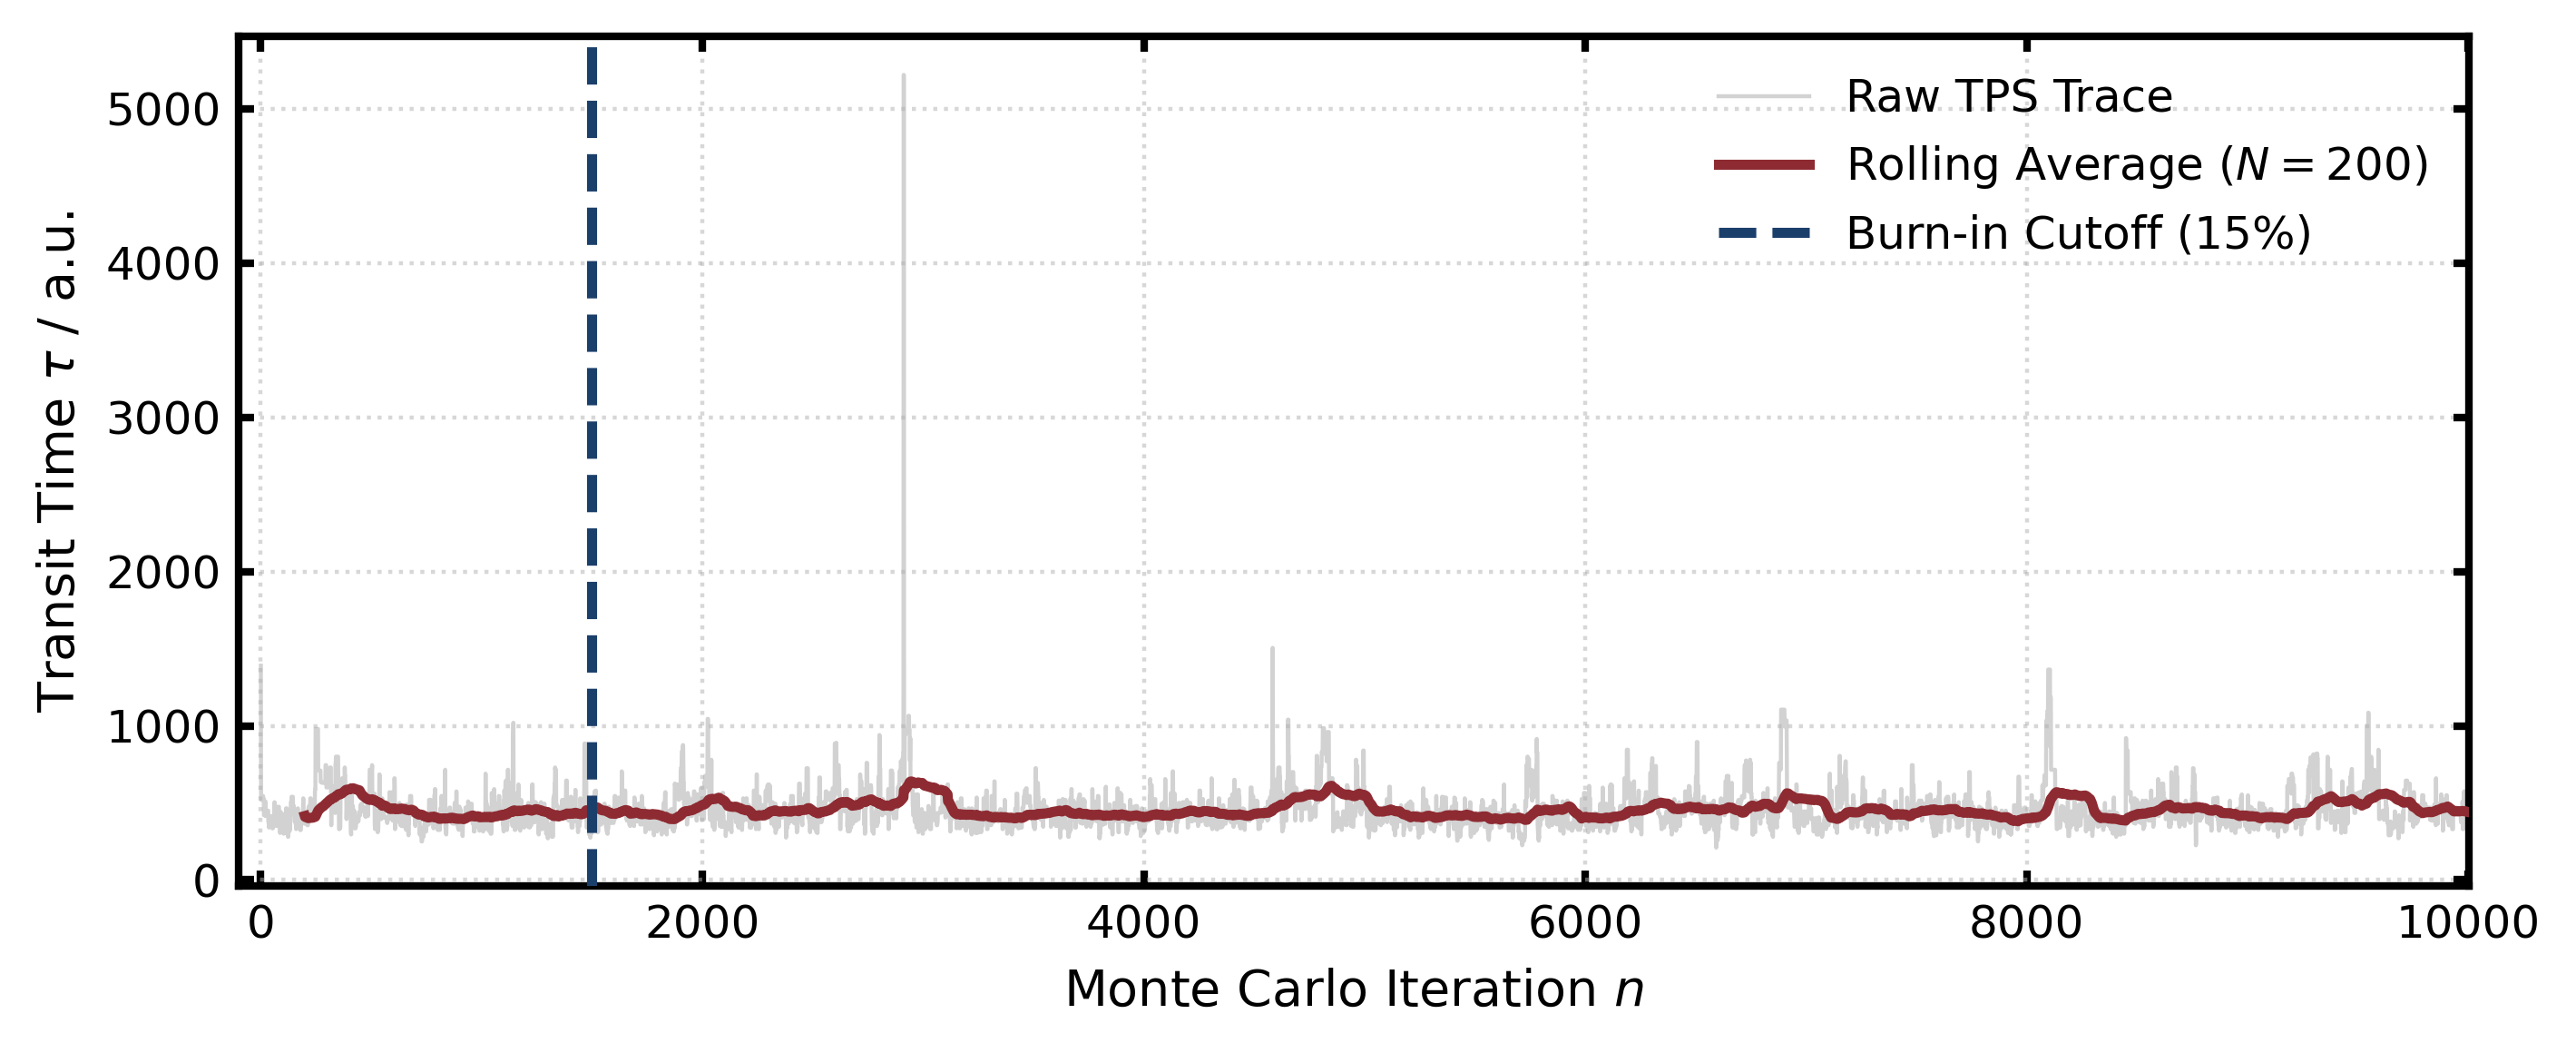

In [66]:
def verify_equilibration_publish(tps_ensemble, dt, temp, burn_in_fraction=0.15, window_size=200):
    """
    Plots a highly polished MCMC trace of transit times to visually 
    verify the burn-in period and chain equilibration.
    """
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Double-column width, relatively short to emphasize the horizontal time evolution
    fig, ax = plt.subplots(figsize=(7.2, 3.0), dpi=400)

    # ==========================================
    # 2. DATA PROCESSING (Untouched)
    # ==========================================
    transit_times = []
    for traj in tps_ensemble:
        grid_snaps = [s for s in traj if s.is_grid]
        transit_times.append((len(grid_snaps) - 1) * dt)
        
    transit_times = np.array(transit_times)
    iterations = np.arange(len(transit_times))
    
    kernel = np.ones(window_size) / window_size
    rolling_mean = np.convolve(transit_times, kernel, mode='valid')
    rolling_iters = iterations[window_size - 1:]

    # ==========================================
    # 3. PLOTTING
    # ==========================================
    # Raw trace (faint gray so it provides texture without overwhelming the plot)
    ax.plot(iterations, transit_times, color='gray', alpha=0.35, linewidth=0.8, 
            zorder=1, label='Raw TPS Trace')
    
    # Smoothed trace (Bold Cranberry)
    ax.plot(rolling_iters, rolling_mean, color=cranberry, linewidth=2.0, 
            zorder=3, label=f'Rolling Average ($N={window_size}$)')
    
    # Burn-in Cutoff (Oxford Blue)
    assumed_burn_in = int(len(tps_ensemble) * burn_in_fraction)
    ax.axvline(x=assumed_burn_in, color=oxford_blue, linestyle='--', linewidth=2.0, 
               zorder=4, label=f'Burn-in Cutoff ({int(burn_in_fraction*100)}%)')

    # ==========================================
    # 4. LABELS & FORMATTING
    # ==========================================
    ax.set_xlabel("Monte Carlo Iteration $n$", fontweight='medium')
    ax.set_ylabel(r"Transit Time $\tau$ / a.u.", fontweight='medium')
    
    # Tight bounds to eliminate floating white space on the x-axis
    ax.set_xlim(-100, len(iterations))
    
    # Inward ticks and clean grid
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Minimalist legend, placed in the top right to usually avoid the bulk of the data
    ax.legend(loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(f"MCMC_Equilibration_T{temp}K.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
with open('tps_standard1000K.pkl', 'rb') as f:
    tps_ens = pickle.load(f)

verify_equilibration_publish(tps_ensemble=tps_ens, dt=dt, temp=1000)

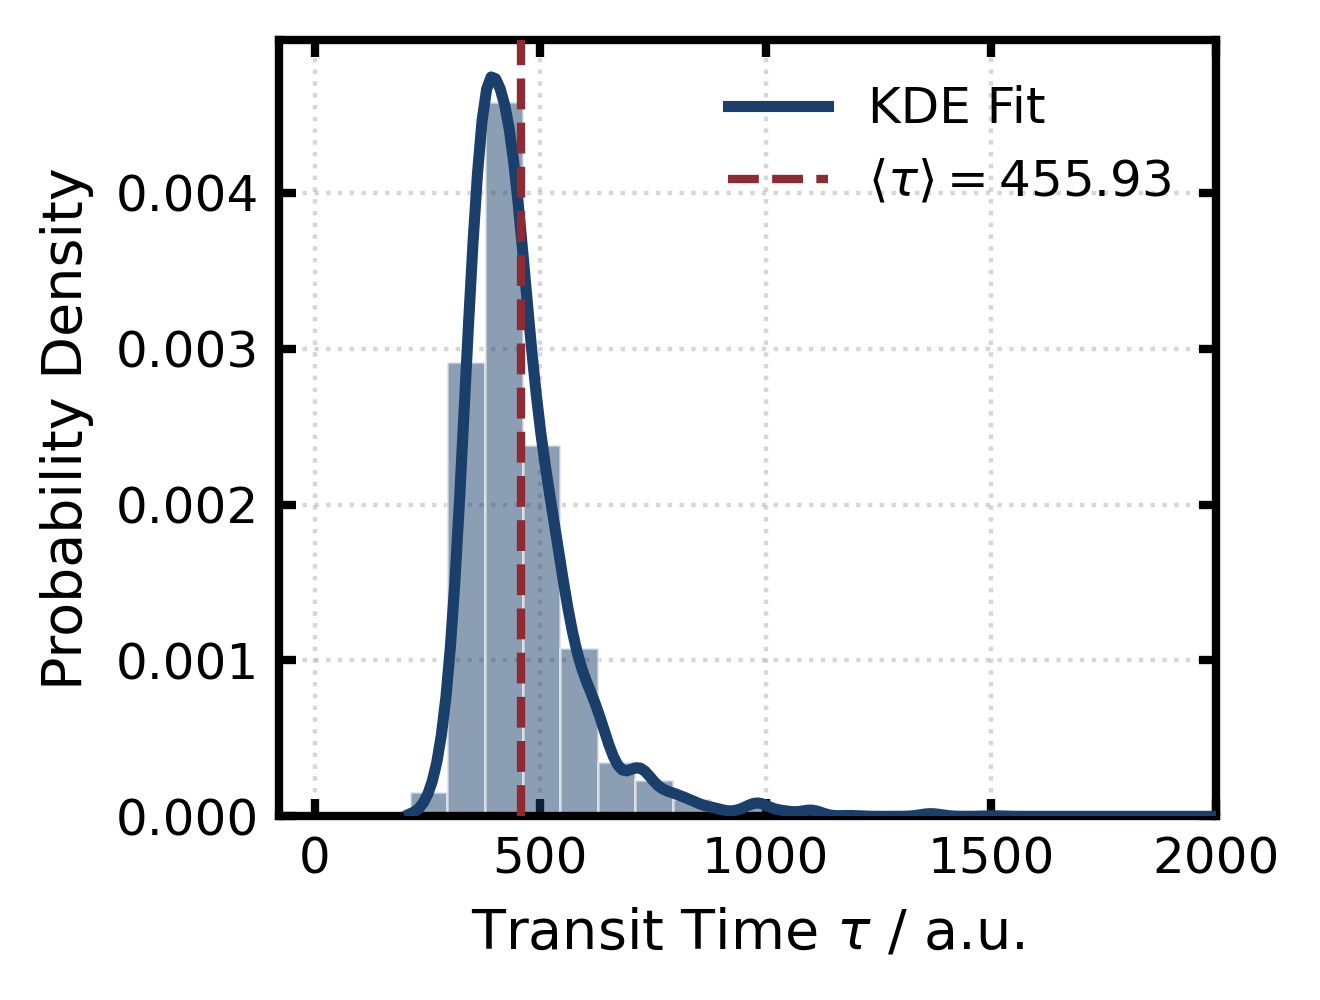

In [67]:
transit_times = []
for traj in tps_ens:
    grid_snaps = [s for s in traj if s.is_grid]
    transit_times.append((len(grid_snaps) - 1) * dt)
mean_time = np.mean(transit_times)

plot_transit_time_dist_publish(transit_times, mean_time)